# **00 Import Library**
Menginstal library yang dibutuhkan untuk proses topic modeling menggunakan BoW + LDA

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.1 MB/s eta 0:00:00


Mengimpor semua library yang digunakan, mulai dari pembuatan Bag of Words, model LDA, hingga evaluasinya (Coherence Score & Perplexity).

In [2]:
# import libraries
import numpy as np
import pandas as pd
import ast
import os
import glob
import os
import gc
import math
import matplotlib.pyplot as plt

# lda
from gensim import corpora
from sklearn.feature_extraction.text import CountVectorizer

from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [3]:
!pip install openpyxl -q

In [4]:
import warnings
warnings.filterwarnings("ignore")

# **01 Load Data**

In [8]:
df_lda = pd.read_excel('/content/data_clean_doaj (1).xlsx')

print(df_lda.shape)
print(df_lda.columns)
df_lda.head()

(3326, 8)
Index(['Main_Keyword', 'Year', 'Title', 'Journal', 'clean_text', 'tokenizing',
       'stopword_removed', 'lemmatization'],
      dtype='object')


,Main_Keyword,Year,Title,Journal,clean_text,tokenizing,stopword_removed,lemmatization
0,sentiment analysis,2020,Automatic Visual Sentiment Analysis with Convo...,International Journal of Industrial Engineerin...,today digital world demands about automated se...,"['today', 'digital', 'world', 'demands', 'abou...","['demands', 'automated', 'sentiment_analysis',...","['demand', 'automated', 'sentiment_analysis', ..."
1,sentiment analysis,2020,Predicting Supervise Machine Learning Performa...,IEEE Access,sentiment_analysis is focused on mining opinio...,"['sentiment_analysis', 'is', 'focused', 'on', ...","['sentiment_analysis', 'mining', 'opinion', 'c...","['sentiment_analysis', 'mining', 'opinion', 'c..."
2,sentiment analysis,2020,Unsupervised Semantic Approach of Aspect-Based...,IEEE Access,aspect_based_sentiment_analysis has recently a...,"['aspect_based_sentiment_analysis', 'has', 're...","['aspect_based_sentiment_analysis', 'attracted...","['aspect_based_sentiment_analysis', 'attracted..."
3,sentiment analysis,2020,Exploring Diverse Features for Sentiment Quant...,IEEE Access,in the era of web online forums blogs and twit...,"['in', 'the', 'era', 'of', 'web', 'online', 'f...","['twitter', 'primary', 'sources', 'views', 'op...","['twitter', 'primary', 'source', 'view', 'opin..."
4,sentiment analysis,2020,Evaluation of Sentiment Analysis in Finance: F...,IEEE Access,financial and economic news is continuously mo...,"['financial', 'and', 'economic', 'news', 'is',...","['financial', 'economic', 'news', 'continuousl...","['financial', 'economic', 'news', 'continuousl..."


In [9]:
def fix_format(text):
    if isinstance(text, list):
        return text
    if isinstance(text, str) and text.strip().startswith('['):
        try:
            return ast.literal_eval(text)
        except Exception:
            return []
    return []

# Kolom yang digunakan: non-lematisasi & lematisasi
COLS_USED = ["stopword_removed", "lemmatization"]

for col in COLS_USED:
    if col in df_lda.columns:
        df_lda[col] = df_lda[col].apply(fix_format)
    else:
        print(f"[WARNING] Kolom '{col}' tidak ditemukan di dataframe.")

print("Kolom yang digunakan:", COLS_USED)
print("\nContoh stopword_removed  :", df_lda["stopword_removed"].iloc[0][:5])
print("Contoh lemmatization     :", df_lda["lemmatization"].iloc[0][:5])


Kolom yang digunakan: ['stopword_removed', 'lemmatization']

Contoh stopword_removed  : ['demands', 'automated', 'sentiment_analysis', 'visual', 'content']
Contoh lemmatization     : ['demand', 'automated', 'sentiment_analysis', 'visual', 'content']


# **02 TUNNING PARAMETER**

## 6.1 Tunning Dictionary (no_below & no_above)

NON LEMMATIZATION
Vocabulary asli : 20597
\Jumlah kata per kombinasi untuk Non-Lematisasi:
    no_below  no_above  vocab_size
0          2      0.01        8957
1          2      0.02        9746
2          2      0.05       10435
3          2      0.30       10794
4          2      0.60       10797
5          2      1.00       10797
6          3      0.01        6410
7          3      0.02        7199
8          3      0.05        7888
9          3      0.30        8247
10         3      0.60        8250
11         3      1.00        8250
12         5      0.01        4236
13         5      0.02        5025
14         5      0.05        5714
15         5      0.30        6073
16         5      0.60        6076
17         5      1.00        6076
18         6      0.01        3626
19         6      0.02        4415
20         6      0.05        5104
21         6      0.30        5463
22         6      0.60        5466
23         6      1.00        5466
24         7      0.01        3132

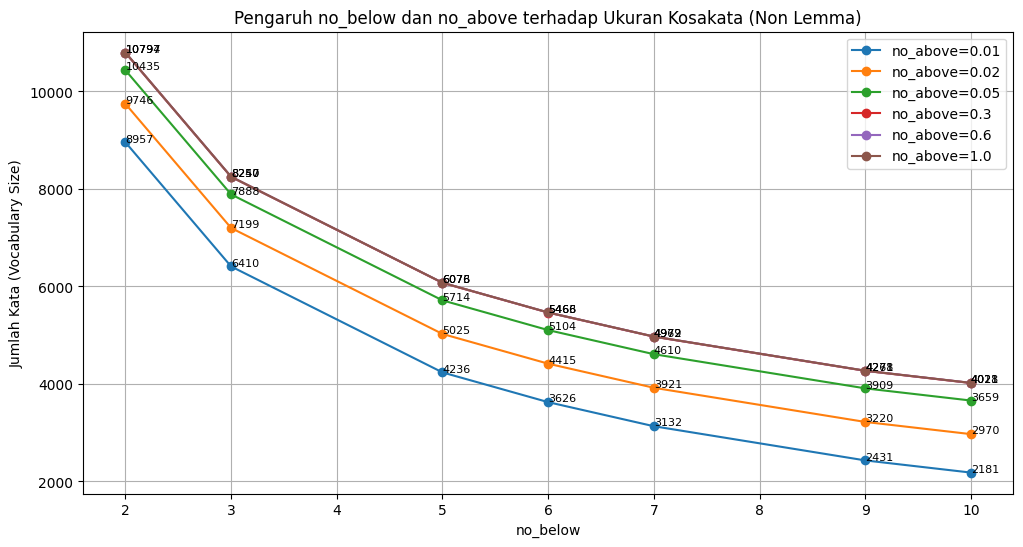

In [10]:
no_below_list = [2, 3, 5, 6, 7, 9, 10]
no_above_list = [0.01, 0.02, 0.05, 0.3, 0.6, 1.0]

results_nonlemma = []
texts_nonlemma = df_lda['stopword_removed'].tolist()

dictionary_asli_nonlemma = corpora.Dictionary(texts_nonlemma)
vocab_asli_nonlemma = len(dictionary_asli_nonlemma)

print("="*50)
print("NON LEMMATIZATION")
print("="*50)
print(f"Vocabulary asli : {vocab_asli_nonlemma}")

print("\Jumlah kata per kombinasi untuk Non-Lematisasi:")
for no_below in no_below_list:

    for no_above in no_above_list:

        dictionary = corpora.Dictionary(texts_nonlemma)

        dictionary.filter_extremes(
            no_below=no_below,
            no_above=no_above
        )

        vocab_size = len(dictionary)

        results_nonlemma.append({
            'no_below': no_below,
            'no_above': no_above,
            'vocab_size': vocab_size
        })

df_tuning_nonlemma = pd.DataFrame(results_nonlemma)
print(df_tuning_nonlemma)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for no_above in no_above_list:

    subset = df_tuning_nonlemma[
        df_tuning_nonlemma['no_above'] == no_above
    ]

    plt.plot(
        subset['no_below'],
        subset['vocab_size'],
        marker='o',
        label=f'no_above={no_above}'
    )

    # label titik
    for x, y in zip(subset['no_below'], subset['vocab_size']):
        plt.text(x, y+10, str(y), fontsize=8)

plt.title('Pengaruh no_below dan no_above terhadap Ukuran Kosakata (Non Lemma)')
plt.xlabel('no_below')
plt.ylabel('Jumlah Kata (Vocabulary Size)')
plt.legend()
plt.grid(True)

plt.show()

LEMMATIZATION
Vocabulary asli : 18483

Jumlah kata per kombinasi untuk Lematisasi:
    no_below  no_above  vocab_size
0          2      0.01        7863
1          2      0.02        8563
2          2      0.05        9187
3          2      0.30        9562
4          2      0.60        9567
5          2      1.00        9567
6          3      0.01        5610
7          3      0.02        6310
8          3      0.05        6934
9          3      0.30        7309
10         3      0.60        7314
11         3      1.00        7314
12         5      0.01        3679
13         5      0.02        4379
14         5      0.05        5003
15         5      0.30        5378
16         5      0.60        5383
17         5      1.00        5383
18         6      0.01        3164
19         6      0.02        3864
20         6      0.05        4488
21         6      0.30        4863
22         6      0.60        4868
23         6      1.00        4868
24         7      0.01        2739
25     

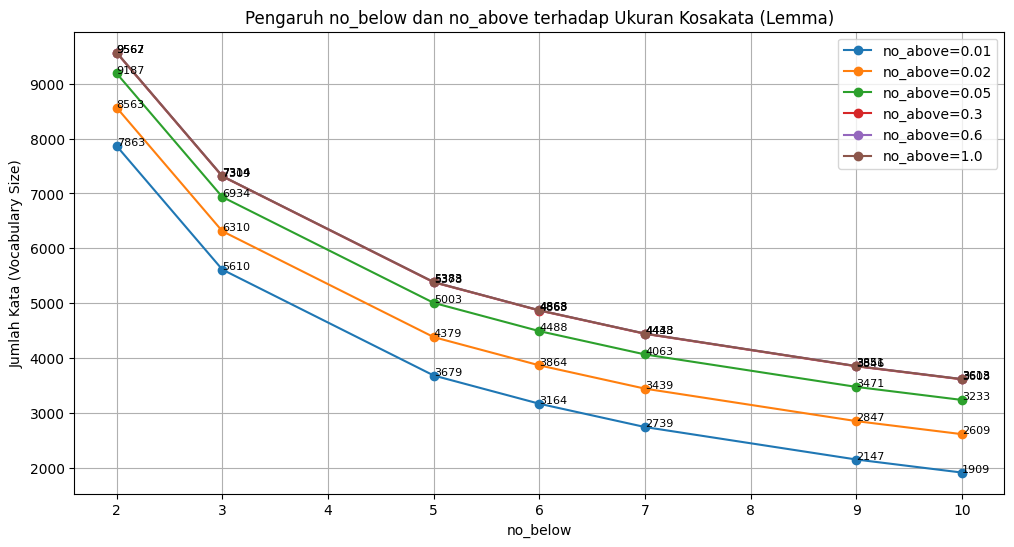

In [11]:
results_lemma = []

texts_lemma  = df_lda['lemmatization'].tolist()
dictionary_asli_lemma = corpora.Dictionary(texts_lemma)
vocab_asli_lemma = len(dictionary_asli_lemma)

print("="*50)
print("LEMMATIZATION")
print("="*50)
print(f"Vocabulary asli : {vocab_asli_lemma}")


print("\nJumlah kata per kombinasi untuk Lematisasi:")
for no_below in no_below_list:

    for no_above in no_above_list:

        dictionary = corpora.Dictionary(texts_lemma )

        dictionary.filter_extremes(
            no_below=no_below,
            no_above=no_above
        )

        vocab_size = len(dictionary)

        results_lemma.append({
            'no_below': no_below,
            'no_above': no_above,
            'vocab_size': vocab_size
        })

df_tuning_lemma = pd.DataFrame(results_lemma)
print(df_tuning_lemma)

plt.figure(figsize=(12,6))

for no_above in no_above_list:

    subset = df_tuning_lemma[
        df_tuning_lemma['no_above'] == no_above
    ]

    plt.plot(
        subset['no_below'],
        subset['vocab_size'],
        marker='o',
        label=f'no_above={no_above}'
    )

    for x, y in zip(subset['no_below'], subset['vocab_size']):
        plt.text(x, y+10, str(y), fontsize=8)

plt.title('Pengaruh no_below dan no_above terhadap Ukuran Kosakata (Lemma)')
plt.xlabel('no_below')
plt.ylabel('Jumlah Kata (Vocabulary Size)')
plt.legend()
plt.grid(True)

plt.show()

no_below=3 dipilih karena kata yang muncul di hanya 1–2 artikel dari seluruh corpus DOAJ hampir pasti tidak akan membentuk topik yang bermakna, tapi kata yang sudah muncul di 3 dokumen berbeda mulai menunjukkan pola. Untuk no_above=0.05, nilai ini membuang kata yang terlalu umum lintas artikel tanpa terlalu agresif seperti 0.01 yang bisa ikut membuang kata metodologi penting. Kombinasi keduanya menghasilkan reduksi 57–66% dari vocab asli, yang cukup bersih tanpa kehilangan terlalu banyak istilah teknis yang relevan.

In [12]:
NO_BELOW_NONLEMMA = 5       # ← ganti sesuai hasil tuning
NO_ABOVE_NONLEMMA = 0.05    # ← ganti sesuai hasil tuning

NO_BELOW_LEMMA    = 5       # ← ganti sesuai hasil tuning
NO_ABOVE_LEMMA    = 0.05    # ← ganti sesuai hasil tuning

NUM_TOPICS_TEMP   = 10      # ← angka sementara, ganti setelah tuning num_topics

passes_list = [10, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

print("Parameter yang digunakan:")
print(f"  Non-Lematisasi -> no_below={NO_BELOW_NONLEMMA}, no_above={NO_ABOVE_NONLEMMA}")
print(f"  Lematisasi     -> no_below={NO_BELOW_LEMMA},    no_above={NO_ABOVE_LEMMA}")
print(f"  num_topics (sementara) = {NUM_TOPICS_TEMP}")
print(f"  passes_list            = {passes_list}")


Parameter yang digunakan:
  Non-Lematisasi -> no_below=5, no_above=0.05
  Lematisasi     -> no_below=5,    no_above=0.05
  num_topics (sementara) = 10
  passes_list            = [10, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [13]:
from gensim import corpora, models
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Non-Lematisasi
texts_nonlemma = df_lda['stopword_removed'].tolist()

dict_nonlemma = corpora.Dictionary(texts_nonlemma)
dict_nonlemma.filter_extremes(
    no_below=NO_BELOW_NONLEMMA,
    no_above=NO_ABOVE_NONLEMMA
)
corpus_nonlemma = [dict_nonlemma.doc2bow(t) for t in texts_nonlemma]

# Lematisasi
texts_lemma = df_lda['lemmatization'].tolist()

dict_lemma = corpora.Dictionary(texts_lemma)
dict_lemma.filter_extremes(
    no_below=NO_BELOW_LEMMA,
    no_above=NO_ABOVE_LEMMA
)
corpus_lemma = [dict_lemma.doc2bow(t) for t in texts_lemma]

print("\n=== Corpus siap ===")
print(f"  Non-Lematisasi -> vocab: {len(dict_nonlemma)}, docs: {len(corpus_nonlemma)}")
print(f"  Lematisasi     -> vocab: {len(dict_lemma)},    docs: {len(corpus_lemma)}")


=== Corpus siap ===
  Non-Lematisasi -> vocab: 5714, docs: 3326
  Lematisasi     -> vocab: 5003,    docs: 3326


In [14]:
print("=" * 55)
print("  TUNING PASSES -- NON-LEMATISASI")
print("=" * 55)

results_passes_nonlemma = []

for p in passes_list:
    lda = models.LdaModel(
        corpus      = corpus_nonlemma,
        id2word     = dict_nonlemma,
        num_topics  = NUM_TOPICS_TEMP,
        passes      = p,
        random_state= 42,
        alpha       = "auto",
        eta         = "auto"
    )
    coherence = CoherenceModel(
        model      = lda,
        texts      = texts_nonlemma,
        dictionary = dict_nonlemma,
        coherence  = "c_v"
    ).get_coherence()

    perplexity = lda.log_perplexity(corpus_nonlemma)

    results_passes_nonlemma.append({
        "passes"    : p,
        "coherence" : coherence,
        "perplexity": perplexity
    })
    print(f"  passes={p:2d}  |  coherence={coherence:.4f}  |  log-perplexity={perplexity:.4f}")

df_passes_nonlemma = pd.DataFrame(results_passes_nonlemma)

  TUNING PASSES -- NON-LEMATISASI
  passes=10  |  coherence=0.4257  |  log-perplexity=-8.1029
  passes=15  |  coherence=0.4352  |  log-perplexity=-8.0859
  passes=20  |  coherence=0.4569  |  log-perplexity=-8.0765
  passes=21  |  coherence=0.4603  |  log-perplexity=-8.0752
  passes=22  |  coherence=0.4614  |  log-perplexity=-8.0740
  passes=23  |  coherence=0.4617  |  log-perplexity=-8.0731
  passes=24  |  coherence=0.4575  |  log-perplexity=-8.0722
  passes=25  |  coherence=0.4577  |  log-perplexity=-8.0713
  passes=26  |  coherence=0.4618  |  log-perplexity=-8.0706
  passes=27  |  coherence=0.4618  |  log-perplexity=-8.0698
  passes=28  |  coherence=0.4618  |  log-perplexity=-8.0691
  passes=29  |  coherence=0.4619  |  log-perplexity=-8.0685
  passes=30  |  coherence=0.4619  |  log-perplexity=-8.0678


In [15]:
print("=" * 55)
print("  TUNING PASSES -- LEMATISASI")
print("=" * 55)

results_passes_lemma = []

for p in passes_list:
    lda = models.LdaModel(
        corpus      = corpus_lemma,
        id2word     = dict_lemma,
        num_topics  = NUM_TOPICS_TEMP,
        passes      = p,
        random_state= 42,
        alpha       = "auto",
        eta         = "auto"
    )
    coherence = CoherenceModel(
        model      = lda,
        texts      = texts_lemma,
        dictionary = dict_lemma,
        coherence  = "c_v"
    ).get_coherence()

    perplexity = lda.log_perplexity(corpus_lemma)

    results_passes_lemma.append({
        "passes"    : p,
        "coherence" : coherence,
        "perplexity": perplexity
    })
    print(f"  passes={p:2d}  |  coherence={coherence:.4f}  |  log-perplexity={perplexity:.4f}")

df_passes_lemma = pd.DataFrame(results_passes_lemma)

  TUNING PASSES -- LEMATISASI
  passes=10  |  coherence=0.3854  |  log-perplexity=-7.9471
  passes=15  |  coherence=0.3993  |  log-perplexity=-7.9326
  passes=20  |  coherence=0.4089  |  log-perplexity=-7.9251
  passes=21  |  coherence=0.4078  |  log-perplexity=-7.9241
  passes=22  |  coherence=0.4069  |  log-perplexity=-7.9230
  passes=23  |  coherence=0.4069  |  log-perplexity=-7.9221
  passes=24  |  coherence=0.4082  |  log-perplexity=-7.9212
  passes=25  |  coherence=0.4084  |  log-perplexity=-7.9204
  passes=26  |  coherence=0.4087  |  log-perplexity=-7.9197
  passes=27  |  coherence=0.4074  |  log-perplexity=-7.9190
  passes=28  |  coherence=0.4091  |  log-perplexity=-7.9184
  passes=29  |  coherence=0.4065  |  log-perplexity=-7.9179
  passes=30  |  coherence=0.4074  |  log-perplexity=-7.9173


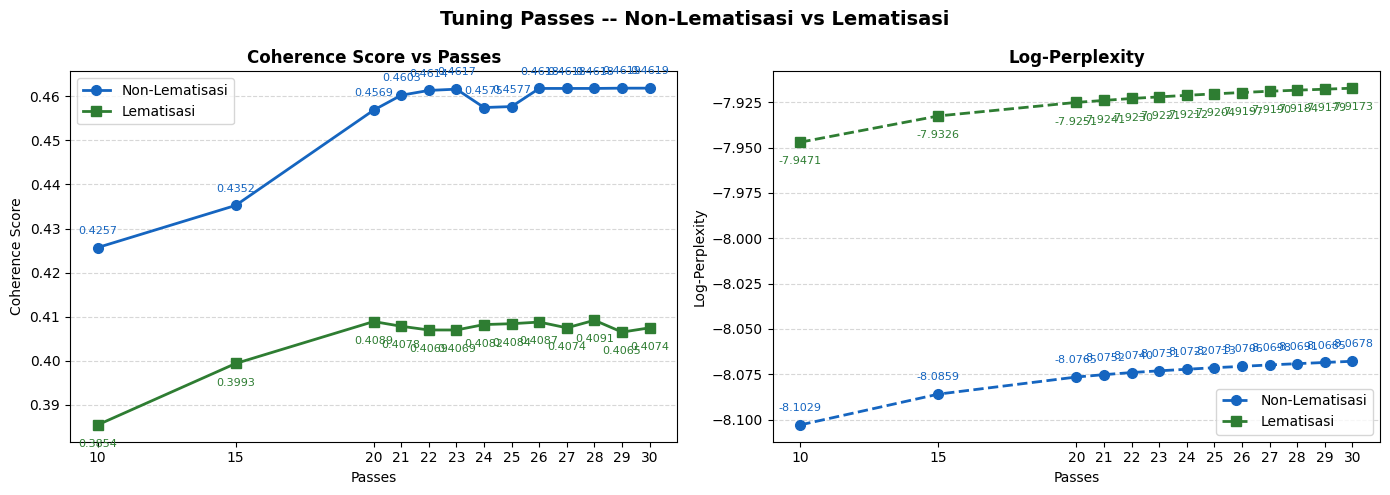

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Tuning Passes -- Non-Lematisasi vs Lematisasi",
             fontsize=14, fontweight="bold")

COLOR_NL = "#1565C0"   # biru  - non-lematisasi
COLOR_L  = "#2E7D32"   # hijau - lematisasi

def annotate_line(ax, x_vals, y_vals, color, offset_y=10):
    for x, y in zip(x_vals, y_vals):
        ax.annotate(f"{y:.4f}", (x, y),
                    textcoords="offset points",
                    xytext=(0, offset_y),
                    ha="center", fontsize=8, color=color)

# ── Grafik 1: Coherence ───────────────────────────────────────
ax = axes[0]
ax.plot(df_passes_nonlemma["passes"], df_passes_nonlemma["coherence"],
        "o-", color=COLOR_NL, linewidth=2, markersize=7, label="Non-Lematisasi")
ax.plot(df_passes_lemma["passes"], df_passes_lemma["coherence"],
        "s-", color=COLOR_L,  linewidth=2, markersize=7, label="Lematisasi")

annotate_line(ax, df_passes_nonlemma["passes"],
              df_passes_nonlemma["coherence"], COLOR_NL, offset_y=10)
annotate_line(ax, df_passes_lemma["passes"],
              df_passes_lemma["coherence"],    COLOR_L,  offset_y=-16)

ax.set_title("Coherence Score vs Passes", fontsize=12, fontweight="bold")
ax.set_xlabel("Passes")
ax.set_ylabel("Coherence Score")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.FixedLocator(passes_list))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)

# ── Grafik 2: Perplexity ──────────────────────────────────────
ax = axes[1]
ax.plot(df_passes_nonlemma["passes"], df_passes_nonlemma["perplexity"],
        "o--", color=COLOR_NL, linewidth=2, markersize=7, label="Non-Lematisasi")
ax.plot(df_passes_lemma["passes"], df_passes_lemma["perplexity"],
        "s--", color=COLOR_L,  linewidth=2, markersize=7, label="Lematisasi")

annotate_line(ax, df_passes_nonlemma["passes"],
              df_passes_nonlemma["perplexity"], COLOR_NL, offset_y=10)
annotate_line(ax, df_passes_lemma["passes"],
              df_passes_lemma["perplexity"],    COLOR_L,  offset_y=-16)

ax.set_title("Log-Perplexity", fontsize=12, fontweight="bold")
ax.set_xlabel("Passes")
ax.set_ylabel("Log-Perplexity")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.FixedLocator(passes_list))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("tuning_passes_bow.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Hasil Final ───────────────────────────────────────────────
best_p_nl = df_passes_nonlemma.loc[df_passes_nonlemma["coherence"].idxmax(), "passes"]
best_p_l  = df_passes_lemma.loc[df_passes_lemma["coherence"].idxmax(), "passes"]

# **02 Pembuatan Dictionary**

In [17]:
def prepare_gensim(text_list, no_below=None, no_above=None):
    dictionary = corpora.Dictionary(text_list)

    if no_below is not None and no_above is not None:
        dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(text) for text in text_list]

    return dictionary, corpus

no_below_values = [5]
no_above_values = [0.05, 0.6]

# no_below_values = [None, 2, 5, 7]
# no_above_values = [None, 0.2, 0.6, 0.8]

## 2.1 Pembuatan Corpus

### 2.1.1 Skenario 1: Data Tanpa Lemmatization

In [18]:
gensim_skenario1 = {}

for nb in no_below_values:
    for na in no_above_values:

        if nb is None and na is None:
            label = f"no_filter"
        elif nb is not None and na is not None:
            label = f"nb{nb}_na{na}"
        else:
            continue

        dictionary, corpus = prepare_gensim(
            df_lda['stopword_removed'].tolist(), nb, na
        )

        gensim_skenario1[label] = {
            "dict": dictionary,
            "corpus": corpus,
            "no_below": nb,
            "no_above": na
        }

### 2.1.2 Skenario 2: Data Dengan Lemmatization

In [19]:
gensim_skenario2 = {}

for nb in no_below_values:
    for na in no_above_values:

        if nb is None and na is None:
            label = "no_filter"
        elif nb is not None and na is not None:
            label = f"nb{nb}_na{na}"
        else:
            continue

        dictionary, corpus = prepare_gensim(
            df_lda["lemmatization"].tolist(), nb, na
        )

        gensim_skenario2[label] = {
            "dict": dictionary,
            "corpus": corpus,
            "no_below": nb,
            "no_above": na
        }

In [20]:
summary = []

def summarize(data, nama):
    for label, val in data.items():
        summary.append({
            "skenario": nama,
            "eksperimen": label,
            "no_below": val["no_below"],
            "no_above": val["no_above"],
            "jumlah_vocab": len(val["dict"]),
            "jumlah_dokumen": len(val["corpus"])
        })

summarize(gensim_skenario1, "non lematisasi")
summarize(gensim_skenario2, "lematisasi")

df_vocab_summary = pd.DataFrame(summary)\
    .sort_values(by="jumlah_vocab", ascending=False)\
    .reset_index(drop=True)

print(f"Total model yang terbentuk: {len(df_vocab_summary)}")
display(df_vocab_summary)

Total model yang terbentuk: 4


,skenario,eksperimen,no_below,no_above,jumlah_vocab,jumlah_dokumen
0,non lematisasi,nb5_na0.6,5,0.60,6076,3326
1,non lematisasi,nb5_na0.05,5,0.05,5714,3326
2,lematisasi,nb5_na0.6,5,0.60,5383,3326
3,lematisasi,nb5_na0.05,5,0.05,5003,3326


# **03 Topic Modeling menggunakan LDA**

### 3.1 Evaluasi Kombinasi Topik & Passes


In [21]:
passes_list = [25]

def evaluate_lda_multi_passes(corpus, dictionary, texts, passes_list, start=2, limit=16, step=1):

    results = []
    topic_range = list(range(start, limit, step))

    for p in passes_list:
        print(f"\n🔁 Evaluasi passes = {p}")

        for k in topic_range:

            model = LdaModel(
                corpus=corpus,
                id2word=dictionary,
                num_topics=k,
                passes=p,
                alpha='auto',
                eta='auto',
                random_state=42
            )

            cm = CoherenceModel(
                model=model,
                texts=texts,
                dictionary=dictionary,
                coherence='c_v'
            )

            coh = cm.get_coherence()
            perp = model.log_perplexity(corpus)

            results.append({
                "k": k,
                "passes": p,
                "coherence": coh,
                "perplexity": perp,
                "model": model
            })

            print(f"k={k} | passes={p} | coh={coh:.4f} | perp={perp:.2f}")

    return pd.DataFrame(results)

## Ekstraksi Informasi Topik

In [22]:
def extract_topic_info(lda_model, num_words=10):

    topic_info = []

    raw_topics = lda_model.show_topics(
        num_topics=-1,
        num_words=num_words,
        formatted=False
    )

    for topic_id, word_list in raw_topics:

        prob_str = " + ".join([
            f'{prob:.4f}*"{word}"'
            for word, prob in word_list
        ])

        keywords = ", ".join([
            word.title()
            for word, prob in word_list
        ])

        topic_info.append({
            "Topik ID": topic_id + 1,
            "Kata Kunci Dominan": keywords,
            "Rumus Probabilitas": prob_str
        })

    return pd.DataFrame(topic_info)

## Distribusi Topik Dokumen

In [23]:
def get_topic_distribution_full(lda_model, corpus, num_topics):
    all_vectors = []
    dominant_topics = []

    for doc in corpus:
        # Ambil semua topik dengan probabilitas, bahkan yang 0
        topics = lda_model.get_document_topics(doc, minimum_probability=0)

        # Inisialisasi vector sesuai k
        vec = [0.0] * num_topics
        for topic_id, prob in topics:
            if topic_id < num_topics:
                vec[topic_id] = prob

        all_vectors.append(vec)

        # Ambil topik dominan
        dominant_topic, prob = max(topics, key=lambda x: x[1])
        dominant_topics.append((dominant_topic + 1, prob))

    return np.array(all_vectors), dominant_topics

## Penyimpanan Hasil Topic Modeling

In [24]:
def save_lda_outputs(
    df_best,
    df_hasil,
    gensim_dict,
    texts,
    df_source,
    text_col,
    skenario_name
):

    # baut folder
    base_topic_path = f"lda_results/{skenario_name}_topics"
    base_data_path  = f"lda_dataset/{skenario_name}"

    os.makedirs(base_topic_path, exist_ok=True)
    os.makedirs(base_data_path, exist_ok=True)

    print(f"\nMenyimpan hasil untuk skenario: {skenario_name}")

    for _, row in df_best.iterrows():

        label  = row["eksperimen"]
        k      = int(row["k"])
        passes = int(row["passes"])

        print(f"\n📌 {label} | k={k} | passes={passes}")

        # ambil model dari df_hasil
        model_row = df_hasil[
            (df_hasil["eksperimen"] == label) &
            (df_hasil["k"] == k) &
            (df_hasil["passes"] == passes)
        ]

        if model_row.empty:
            print("⚠️ model tidak ditemukan, skip")
            continue

        lda_model = model_row.iloc[0]["model"]
        corpus    = gensim_dict[label]["corpus"]

        df_topic = extract_topic_info(lda_model, num_words=15)

        topic_path = f"{base_topic_path}/{label}_k{k}_p{passes}.xlsx"
        df_topic.to_excel(topic_path, index=False)

        print(f"✔ topic saved: {topic_path}")

        lda_vecs, dom_topics = get_topic_distribution_full(lda_model, corpus, k)

        df_out = pd.DataFrame({
            "doc_id": df_source.index,
            "Year": df_source["Year"],
            "clean_text": df_source["clean_text"],
            text_col: df_source[text_col]
        })

        # kolom topik
        for i in range(k):
            df_out[f"topic_{i+1}"] = lda_vecs[:, i]

        # topik dominan
        df_out["topik_lda"] = [t[0] for t in dom_topics]
        df_out["prob_topik"]    = [t[1] for t in dom_topics]

        data_path = f"{base_data_path}/{label}_k{k}_p{passes}.csv"
        df_out.to_csv(data_path, index=False)

        print(f"✔ dataset saved: {data_path}")

In [25]:
def plot_lda_results(df_result, title):
    passes_list = sorted(df_result['passes'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # untuk coherence
    for p in passes_list:
        df_p = df_result[df_result['passes'] == p]
        axes[0].plot(df_p['k'], df_p['coherence'], marker='o', label=f'passes={p}')

    axes[0].set_title("Coherence Score")
    axes[0].set_xlabel("Jumlah Topik (k)")
    axes[0].set_ylabel("Coherence")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # untuk perplecity
    for p in passes_list:
        df_p = df_result[df_result['passes'] == p]
        axes[1].plot(df_p['k'], df_p['perplexity'], marker='x', linestyle='--', label=f'passes={p}')

    axes[1].set_title("Perplexity Score")
    axes[1].set_xlabel("Jumlah Topik (k)")
    axes[1].set_ylabel("Perplexity")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Evaluasi LDA: {title}")
    plt.tight_layout()
    plt.show()

In [26]:
def plot_best_lda(df_best, df_all, title_prefix=""):

    grouped = df_best.groupby(["eksperimen", "passes"])

    for (exp, p), df_subset in grouped:

        df_plot = df_all[
            (df_all["eksperimen"] == exp) &
            (df_all["passes"] == p)].sort_values("k")

        k_vals = df_plot["k"].values
        coh_vals = df_plot["coherence"].values
        perp_vals = df_plot["perplexity"].values

        best_row = df_subset.iloc[0]
        best_k = best_row["k"]
        best_coh = best_row["coherence"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(k_vals, coh_vals, marker='o')
        axes[0].set_title(f"Coherence\n{exp} | passes={p}")
        axes[0].set_xlabel("Jumlah Topik (k)")
        axes[0].set_ylabel("Coherence")
        axes[0].grid(True, alpha=0.3)

        for x, y in zip(k_vals, coh_vals):
            axes[0].annotate(f"{y:.3f}", (x, y),
                             textcoords="offset points",
                             xytext=(0,8),
                             ha='center',
                             fontsize=8)

        axes[0].scatter(best_k, best_coh,
                        s=120,
                        facecolors='none',
                        edgecolors='red',
                        linewidths=2)

        axes[1].plot(k_vals, perp_vals, marker='x', linestyle='--')
        axes[1].set_title(f"Perplexity\n{exp} | passes={p}")
        axes[1].set_xlabel("Jumlah Topik (k)")
        axes[1].set_ylabel("Perplexity")
        axes[1].grid(True, alpha=0.3)

        for x, y in zip(k_vals, perp_vals):
            axes[1].annotate(f"{y:.2f}", (x, y),
                             textcoords="offset points",
                             xytext=(0,-10),
                             ha='center',
                             fontsize=8)

        plt.subplots_adjust(wspace=0.35)

        plt.suptitle(f"{title_prefix} | {exp} | passes={p}", fontsize=12)
        plt.show()

## 3.1 Hyperparameter Tuning (Cari K/Jumlah Topik Terbaik)

### 3.1.1 Tuning Model Unigram (Non Lemma)


📊 Eksperimen: nb5_na0.05

🔁 Evaluasi passes = 25


k=2 | passes=25 | coh=0.3079 | perp=-8.09
k=3 | passes=25 | coh=0.3615 | perp=-8.04
k=4 | passes=25 | coh=0.3463 | perp=-8.03
k=5 | passes=25 | coh=0.4061 | perp=-8.03
k=6 | passes=25 | coh=0.4307 | perp=-8.04
k=7 | passes=25 | coh=0.3987 | perp=-8.06
k=8 | passes=25 | coh=0.4157 | perp=-8.06
k=9 | passes=25 | coh=0.4134 | perp=-8.06
k=10 | passes=25 | coh=0.4577 | perp=-8.07
k=11 | passes=25 | coh=0.4224 | perp=-8.08
k=12 | passes=25 | coh=0.4566 | perp=-8.09
k=13 | passes=25 | coh=0.4783 | perp=-8.10
k=14 | passes=25 | coh=0.4704 | perp=-8.13
k=15 | passes=25 | coh=0.4443 | perp=-8.13


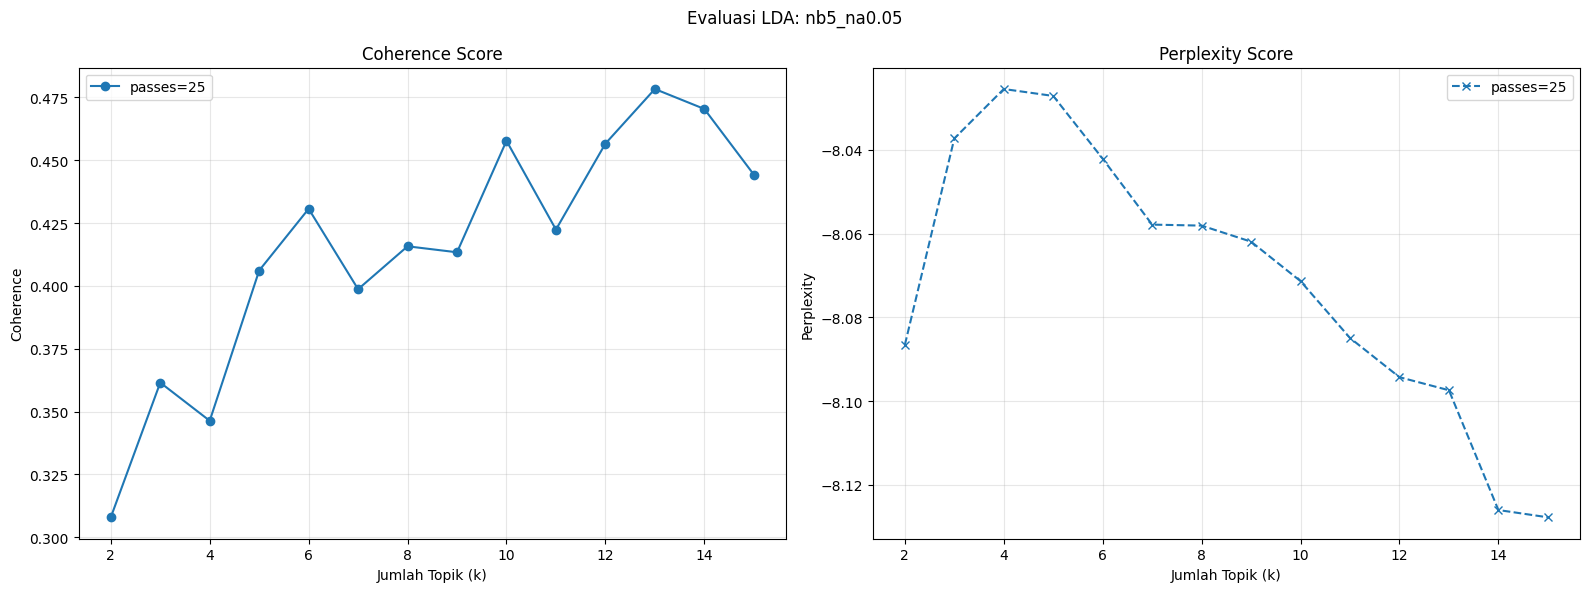


📊 Eksperimen: nb5_na0.6

🔁 Evaluasi passes = 25


k=2 | passes=25 | coh=0.3711 | perp=-7.74


k=3 | passes=25 | coh=0.5243 | perp=-7.65
k=4 | passes=25 | coh=0.5885 | perp=-7.63
k=5 | passes=25 | coh=0.6052 | perp=-7.60
k=6 | passes=25 | coh=0.5935 | perp=-7.59
k=7 | passes=25 | coh=0.5837 | perp=-7.60
k=8 | passes=25 | coh=0.5971 | perp=-7.59
k=9 | passes=25 | coh=0.5668 | perp=-7.60
k=10 | passes=25 | coh=0.5912 | perp=-7.60
k=11 | passes=25 | coh=0.5141 | perp=-7.61
k=12 | passes=25 | coh=0.5357 | perp=-7.61
k=13 | passes=25 | coh=0.5454 | perp=-7.62
k=14 | passes=25 | coh=0.5617 | perp=-7.62
k=15 | passes=25 | coh=0.5385 | perp=-7.62


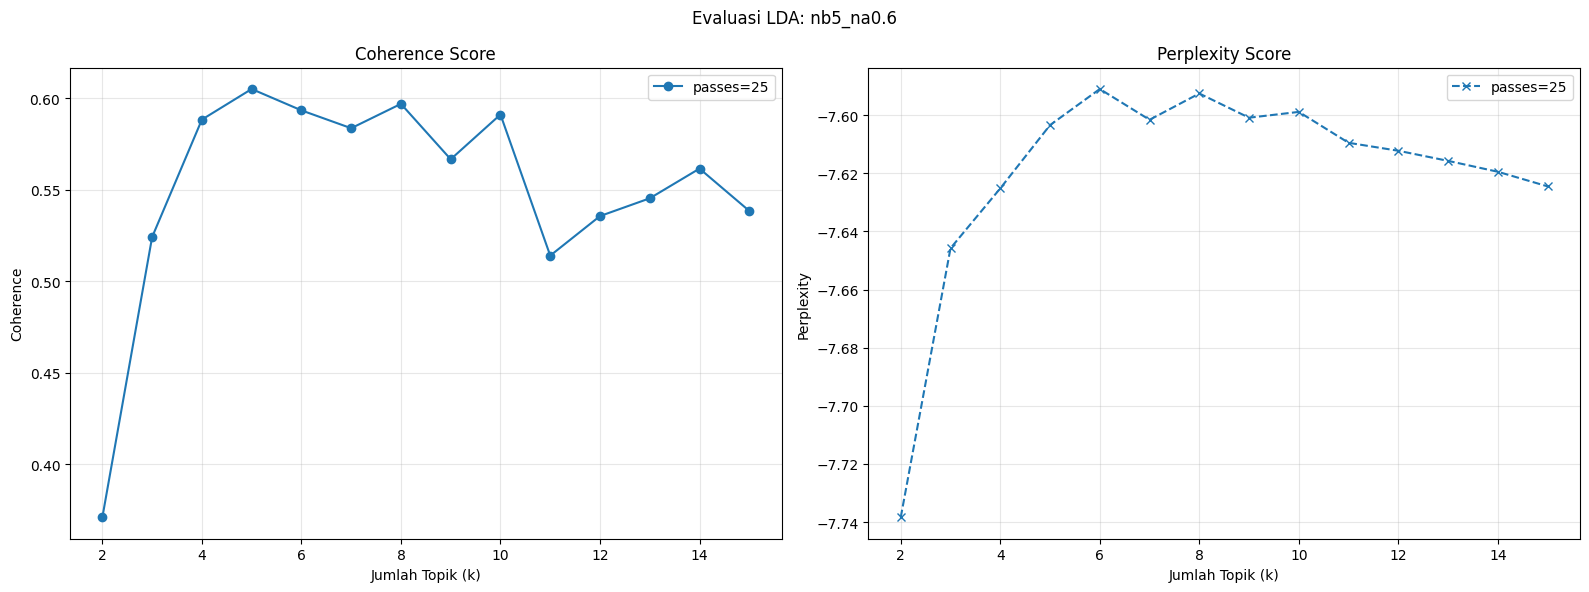

In [27]:
df_hasil_nonlemma = []

for label, data in gensim_skenario1.items():

    print(f"\n📊 Eksperimen: {label}")

    df_result = evaluate_lda_multi_passes(
        corpus=data['corpus'],
        dictionary=data['dict'],
        texts=df_lda['stopword_removed'].tolist(),
        passes_list=passes_list
    )

    df_result["eksperimen"] = label
    df_result["no_below"] = data["no_below"]
    df_result["no_above"] = data["no_above"]

    df_hasil_nonlemma.append(df_result)

    plot_lda_results(df_result, label)

df_hasil_nonlemma = pd.concat(df_hasil_nonlemma).reset_index(drop=True)

In [28]:
df_nonlemma_best = df_hasil_nonlemma.loc[df_hasil_nonlemma.groupby(['eksperimen', 'passes'])['coherence'].idxmax()].reset_index(drop=True)

df_nonlemma_best = df_nonlemma_best.sort_values( # urutkan dari terbaik
    by=["passes", "coherence"], ascending=False).reset_index(drop=True)

print(f"Jumlah model terbaik (eksperimen x passes): {len(df_nonlemma_best)}")
display(df_nonlemma_best)

Jumlah model terbaik (eksperimen x passes): 2


,k,passes,coherence,perplexity,model,eksperimen,no_below,no_above
0,5,25,0.605171,-7.603399,"LdaModel<num_terms=6076, num_topics=5, decay=0...",nb5_na0.6,5,0.60
1,13,25,0.478314,-8.097389,"LdaModel<num_terms=5714, num_topics=13, decay=...",nb5_na0.05,5,0.05


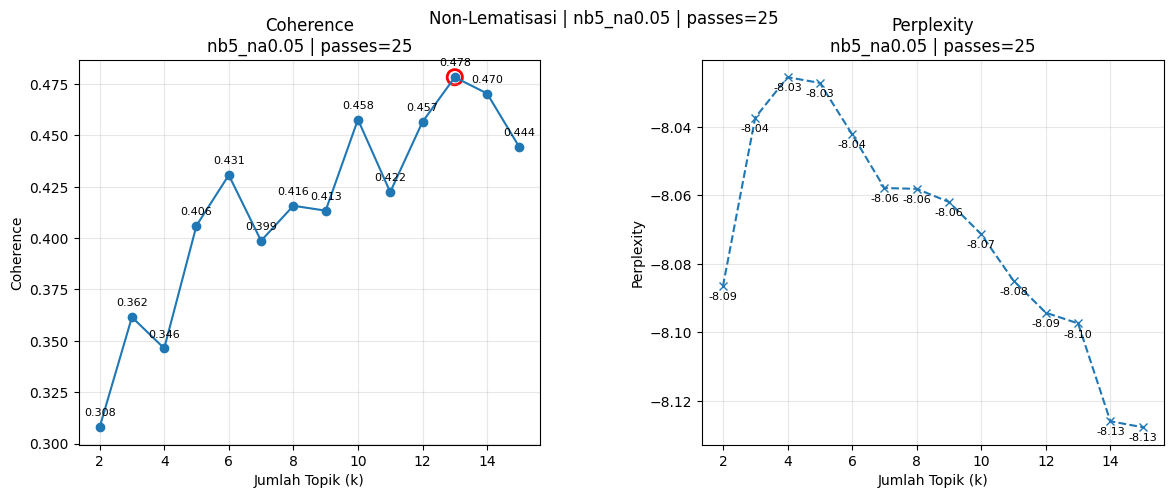

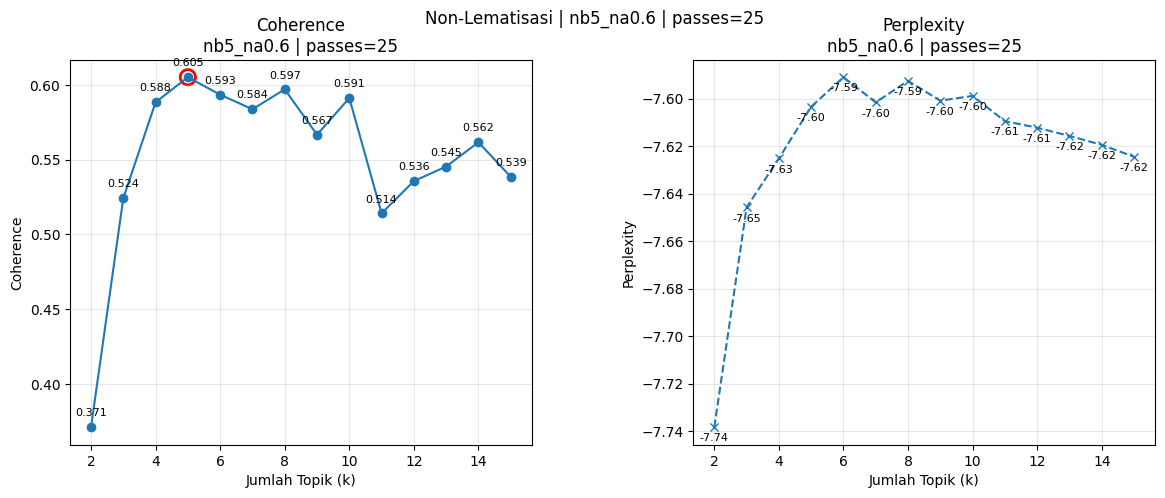

In [29]:
plot_best_lda(
    df_best=df_nonlemma_best, df_all=df_hasil_nonlemma,
    title_prefix="Non-Lematisasi")

In [ ]:
# save_lda_outputs(
#     df_best=df_nonlemma_best,
#     df_hasil=df_hasil_nonlemma,
#     gensim_dict=gensim_skenario1,
#     texts=df_lda['stopword_removed'].tolist(),
#     df_source=df_lda,
#     text_col="stopword_removed",
#     skenario_name="non_lematisasi"
# )

In [30]:
os.makedirs("lda_results/nonlemma_topics", exist_ok=True)

for _, row in df_nonlemma_best.iterrows():

    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    print(f"\n{'='*60}")
    print(f"  {label} | k={k} | passes={passes}")
    print(f"{'='*60}")

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == label) &
        (df_hasil_nonlemma["k"] == k) &
        (df_hasil_nonlemma["passes"] == passes)
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]

    df_topic = extract_topic_info(lda_model, num_words=15)

    # Print full tanpa terpotong
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_rows", None)
    print(df_topic[["Topik ID", "Kata Kunci Dominan", "Rumus Probabilitas"]].to_string(index=False))
    pd.reset_option("display.max_colwidth")
    pd.reset_option("display.max_rows")

    # Simpan CSV
    output_path = (
        f"lda_results/nonlemma_topics/"
        f"{label}_k{k}_p{passes}_topics.csv"
    )
    df_topic.to_csv(output_path, index=False)
    print(f"\n✔ saved: {output_path}")


  nb5_na0.6 | k=5 | passes=25
 Topik ID                                                                                                                                                                     Kata Kunci Dominan                                                                                                                                                                                                                                                                                                                          Rumus Probabilitas
        1                                                       Topic, Sentiment_Analysis, Social, Media, Topics, Public, Modeling, User, Reviews, Negative, X, Positive, Users, Twitter, Tweets                                                       0.0184*"topic" + 0.0155*"sentiment_analysis" + 0.0141*"social" + 0.0109*"media" + 0.0096*"topics" + 0.0095*"public" + 0.0088*"modeling" + 0.0086*"user" + 0.0085*"reviews" + 0.0065*"negative" + 0.00

In [ ]:
# Model 1: unigram_nb5_na0.6 | k=5 | passes=25
labels_nb5_na06_k5 = {
     1: "Sentiment Media Sosial",
     2: "Predictive Analytics",
     3: "Prediksi Data & Feature Reduction",
     4: "Forecasting Time Series",
     5: "Feature Selection ML",
}


# Model 2: unigram_nb5_na0.05 | k=13 | passes=25
labels_nb5_na005_k13 = {
    1:  "Image Spectral Processing",
    2:  "BERT Aspect Sentiment",
    3:  "Education Technology",
    4:  "Cyber Attack Detection",
    5:  "Financial Market Prediction",
    6:  "Fault Detection",
    7:  "Energy Load Forecast",
    8:  "IoT Smart System",
    9:  "COVID News Market",
    10: "Predictive Maintenance",
    11: "Medical Diagnosis AI",
    12: "Customer Review Sentiment",
    13: "Smart City Infrastructure",
}

def add_labels(df_topic, label_dict):

    df = df_topic.copy()

    df.insert(
        1,
        "Label Topik",
        df["Topik ID"].map(label_dict))
    return df


os.makedirs("lda_results", exist_ok=True)
output_excel = "lda_results/nonlemma_topics_labeled.xlsx"


configs = [

    {"eksperimen": "unigram_nb5_na0.6", "k": 5, "passes": 25, "labels": labels_nb5_na06_k5, "sheet": "nb5_na0.6_k5"},

    {"eksperimen": "unigram_nb5_na0.05", "k": 13, "passes": 25, "labels": labels_nb5_na005_k13,
        "sheet": "nb5_na0.05_k13"
    }]


with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    for cfg in configs:

        print(f"\n{'='*60}")
        print(f"{cfg['eksperimen']} | k={cfg['k']} | passes={cfg['passes']}")
        print(f"{'='*60}")

        # ambil model
        model_row = df_hasil_nonlemma[
            (df_hasil_nonlemma["eksperimen"] == cfg["eksperimen"]) &
            (df_hasil_nonlemma["k"] == cfg["k"]) &
            (df_hasil_nonlemma["passes"] == cfg["passes"])
        ]

        if model_row.empty:
            print("Model tidak ditemukan.")
            continue

        lda_model = model_row.iloc[0]["model"]

        # ekstraksi topik
        df_topic = extract_topic_info(
            lda_model,
            num_words=15
        )

        # tambah label
        df_labeled = add_labels(
            df_topic,
            cfg["labels"]
        )

        # tampilkan
        display(
            df_labeled[
                [
                    "Topik ID",
                    "Label Topik",
                    "Kata Kunci Dominan"
                ]
            ]
        )

        # simpan excel
        df_labeled.to_excel(
            writer, sheet_name=cfg["sheet"], index=False)

        # auto width excel
        ws = writer.sheets[cfg["sheet"]]

        for col in ws.columns:

            max_len = max(
                len(str(cell.value)) if cell.value else 0
                for cell in col
            )

            ws.column_dimensions[
                col[0].column_letter
            ].width = min(max_len + 4, 60)

        print(f"✔ sheet saved: {cfg['sheet']}")

print(f"\n✅ File Excel tersimpan di:\n{output_excel}")


unigram_nb5_na0.6 | k=5 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,Sentiment Media Sosial,"Topic, Sentiment_Analysis, Social, Media, Topi..."
1,2,Predictive Analytics,"Ai, Predictive, Analytics, Systems, Management..."
2,3,Prediksi Data & Feature Reduction,"Prediction, Reduction, Dimensionality, High, A..."
3,4,Forecasting Time Series,"Models, Forecasting, Series, Long_Short_Term_M..."
4,5,Feature Selection ML,"Features, Classification, Accuracy, Selection,..."


✔ sheet saved: nb5_na0.6_k5

unigram_nb5_na0.05 | k=13 | passes=25


,Topik ID,Label Topik,Kata Kunci Dominan
0,1,Image Spectral Processing,"Spatial, Spectral, Fuzzy, Hyperspectral, Matri..."
1,2,BERT Aspect Sentiment,"D_, Aspect, Graph, Arabic, Bert, Texts, Fine, ..."
2,3,Education Technology,"Food, Education, Students, Policy, Business, A..."
3,4,Cyber Attack Detection,"Attacks, Water, Intrusion, Attack, Traffic, Id..."
4,5,Financial Market Prediction,"Financial, Multimodal, Modal, Market, Stock, C..."
5,6,Fault Detection,"Fault, Rf, Gradient, Boosting, Diagnosis, Xgbo..."
6,7,Energy Load Forecast,"Load, Consumption, Grid, Traffic, Mae, Rmse, E..."
7,8,IoT Smart System,"Iot, Cloud, Supply, Devices, Computing, Chain,..."
8,9,COVID News Market,"Covid, News, Pandemic, Tweets, C, Stock, Polit..."
9,10,Predictive Maintenance,"Gas, Project, Life, Maintenance, Construction,..."


✔ sheet saved: nb5_na0.05_k13

✅ File Excel tersimpan di:
lda_results/nonlemma_topics_labeled.xlsx


In [ ]:
df_nonlemma = df_lda.copy()

# fungsi ambil distribusi topik lengkap
def get_topic_distribution(lda_model, corpus, num_topics):
    topic_vectors = []
    dominant_topics = []
    for doc in corpus:
        topics = lda_model.get_document_topics(
            doc,
            minimum_probability=0)
        vec = [0.0] * num_topics

        for topic_id, prob in topics:
            vec[topic_id] = prob
        topic_vectors.append(vec)

        dom_topic, dom_prob = max(
            topics,
            key=lambda x: x[1])
        dominant_topics.append(
            (dom_topic + 1, dom_prob))

    return np.array(topic_vectors), dominant_topics

# konfigurasi model terbaik
configs = [
    {"eksperimen": "unigram_nb5_na0.6", "k": 5, "passes": 25, "labels": labels_nb5_na06_k5},
    {"eksperimen": "unigram_nb5_na0.05", "k": 13, "passes": 25, "labels": labels_nb5_na005_k13}]

In [ ]:
os.makedirs("lda_dataset/nonlemma", exist_ok=True)

# proses gabungkan hasil topic ke data awal
for cfg in configs:

    print(f"\nMemproses {cfg['eksperimen']}")

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == cfg["eksperimen"]) &
        (df_hasil_nonlemma["k"] == cfg["k"]) &
        (df_hasil_nonlemma["passes"] == cfg["passes"])
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]

    corpus = gensim_skenario1[
        cfg["eksperimen"]
    ]["corpus"]

    k = cfg["k"]

    topic_vectors, dominant_topics = get_topic_distribution(
        lda_model,
        corpus,
        k
    )

    # copy data
    df_final = df_nonlemma.copy()

    # rename kolom
    df_final = df_final.rename(
        columns={
            "stopword_removed": "non_lemmatization"
        }
    )

    # ambil kolom penting
    df_final = df_final[
        [
            "Year",
            "clean_text",
            "non_lemmatization"
        ]
    ]

    # tambah probabilitas topik
    for i in range(k):

        df_final[f"topic_{i+1}"] = topic_vectors[:, i]

    # topik dominan
    df_final["topik_dominan"] = [
        x[0] for x in dominant_topics
    ]

    df_final["probabilitas_topik"] = [
        x[1] for x in dominant_topics
    ]

    # label topik
    df_final["label_topik"] = df_final[
        "topik_dominan"
    ].map(cfg["labels"])

    # save csv
    output_path = (
        f"lda_dataset/nonlemma/"
        f"{cfg['eksperimen']}_k{cfg['k']}_p{cfg['passes']}.csv"
    )

    df_final.to_csv(
        output_path,
        index=False
    )

    print(f"✔ saved: {output_path}")
    display(df_final.tail())


Memproses unigram_nb5_na0.6
✔ saved: lda_dataset/nonlemma/unigram_nb5_na0.6_k5_p25.csv


,Year,clean_text,non_lemmatization,topic_1,topic_2,topic_3,topic_4,topic_5,topik_dominan,probabilitas_topik,label_topik
3321,2026,this debate examines how climate change presen...,"[debate, examines, climate, presents, complex,...",0.071864,0.807588,0.119169,0.000680,0.000699,2,0.807588,Predictive Analytics
3322,2026,the current literature on electrical maintenan...,"[current, literature, electrical, maintenance,...",0.000530,0.997370,0.000739,0.000671,0.000690,2,0.997370,Predictive Analytics
3323,2026,this proposes a hybrid automated machine_learn...,"[hybrid, automated, machine_learning, automl, ...",0.000613,0.370672,0.000854,0.092575,0.535286,5,0.535286,Feature Selection ML
3324,2026,the rapid expansion of artificial intelligence...,"[rapid, expansion, artificial, intelligence, a...",0.000554,0.997253,0.000772,0.000701,0.000720,2,0.997253,Predictive Analytics
3325,2026,traditional nursing practices often rely on em...,"[traditional, nursing, practices, often, rely,...",0.000814,0.632493,0.052959,0.159359,0.154375,2,0.632493,Predictive Analytics



Memproses unigram_nb5_na0.05
✔ saved: lda_dataset/nonlemma/unigram_nb5_na0.05_k13_p25.csv


,Year,clean_text,non_lemmatization,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topik_dominan,probabilitas_topik,label_topik
3321,2026,this debate examines how climate change presen...,"[debate, examines, climate, presents, complex,...",0.000921,0.041843,0.431327,0.000491,0.017341,0.000759,0.203052,0.000559,0.173072,0.070903,0.000586,0.000616,0.058528,3,0.431327,Education Technology
3322,2026,the current literature on electrical maintenan...,"[current, literature, electrical, maintenance,...",0.001233,0.017953,0.182676,0.000657,0.000721,0.001016,0.111375,0.148062,0.000915,0.024274,0.000785,0.073345,0.436988,13,0.436988,Smart City Infrastructure
3323,2026,this proposes a hybrid automated machine_learn...,"[hybrid, automated, machine_learning, automl, ...",0.001551,0.001397,0.001341,0.127959,0.019642,0.508368,0.191983,0.000943,0.001152,0.001060,0.000988,0.001039,0.142577,6,0.508368,Fault Detection
3324,2026,the rapid expansion of artificial intelligence...,"[rapid, expansion, artificial, intelligence, a...",0.001358,0.001223,0.490582,0.000725,0.000795,0.018317,0.158180,0.000826,0.001008,0.000928,0.000865,0.077077,0.248116,3,0.490582,Education Technology
3325,2026,traditional nursing practices often rely on em...,"[traditional, nursing, practices, often, rely,...",0.001897,0.001707,0.173544,0.130809,0.001110,0.001563,0.303118,0.001152,0.073278,0.001295,0.249654,0.001269,0.059606,7,0.303118,Energy Load Forecast


In [ ]:
!pip install pyLDAvis -q
pyLDAvis.enable_notebook()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 88.1 MB/s eta 0:00:00


NameError: name 'pyLDAvis' is not defined

In [ ]:
# non-lematisasi

import warnings
warnings.filterwarnings("ignore")

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from IPython.display import display, HTML

pyLDAvis.enable_notebook()

for _, row in df_nonlemma_best.iterrows():

    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    model_row = df_hasil_nonlemma[
        (df_hasil_nonlemma["eksperimen"] == label) &
        (df_hasil_nonlemma["k"] == k) &
        (df_hasil_nonlemma["passes"] == passes)
    ]

    if model_row.empty:
        continue

    lda_model = model_row.iloc[0]["model"]

    corpus = gensim_skenario1[label]["corpus"]
    dictionary = gensim_skenario1[label]["dict"]

    vis = gensimvis.prepare(
        lda_model,
        corpus,
        dictionary,
        sort_topics=False
    )

    display(HTML(f"<h3>{label} | k={k} | passes={passes}</h3>"))
    display(pyLDAvis.display(vis))

### 3.1.2 Tuning Model Lematisasi


📊 Eksperimen: nb5_na0.05

🔁 Evaluasi passes = 25


k=2 | passes=25 | coh=0.3384 | perp=-7.96
k=3 | passes=25 | coh=0.3757 | perp=-7.89
k=4 | passes=25 | coh=0.3487 | perp=-7.87
k=5 | passes=25 | coh=0.3222 | perp=-7.88
k=6 | passes=25 | coh=0.4012 | perp=-7.88
k=7 | passes=25 | coh=0.3752 | perp=-7.89
k=8 | passes=25 | coh=0.4257 | perp=-7.90
k=9 | passes=25 | coh=0.3956 | perp=-7.92
k=10 | passes=25 | coh=0.4084 | perp=-7.92
k=11 | passes=25 | coh=0.4399 | perp=-7.92
k=12 | passes=25 | coh=0.4055 | perp=-7.94
k=13 | passes=25 | coh=0.3883 | perp=-7.95
k=14 | passes=25 | coh=0.3742 | perp=-7.98
k=15 | passes=25 | coh=0.4350 | perp=-7.98


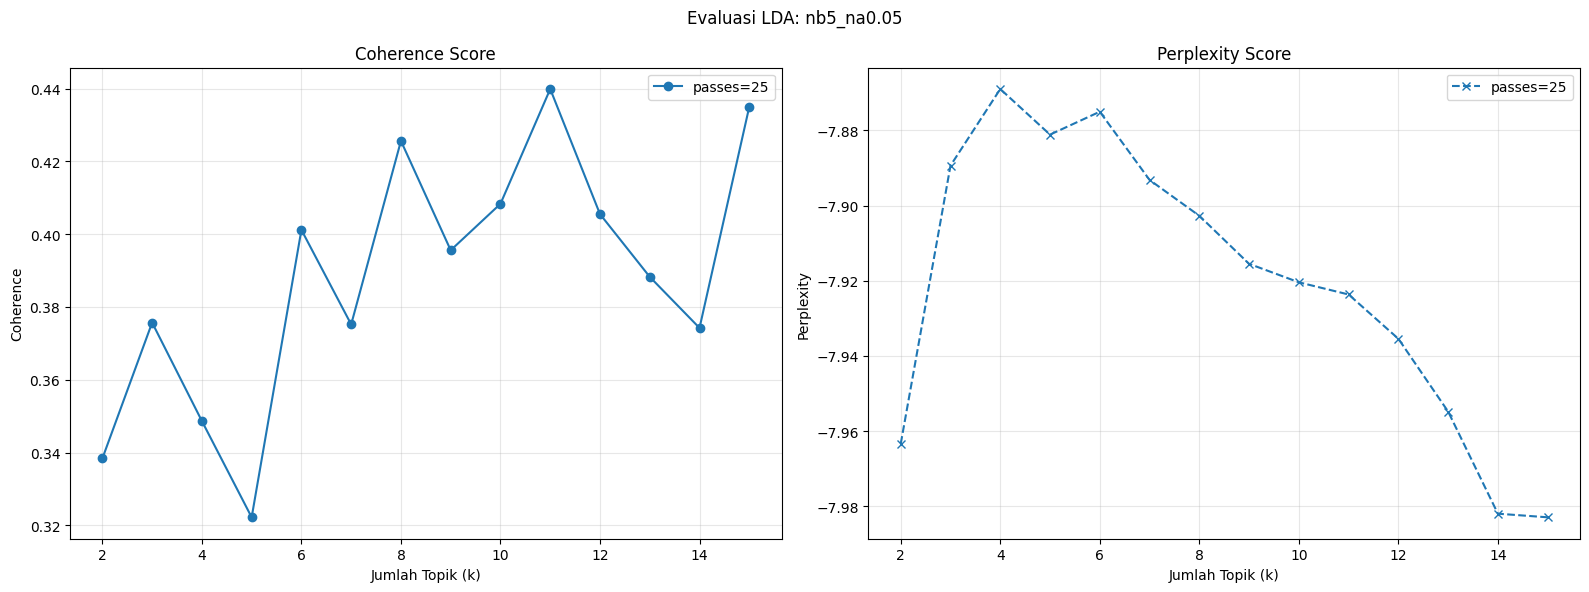


📊 Eksperimen: nb5_na0.6

🔁 Evaluasi passes = 25


k=2 | passes=25 | coh=0.4181 | perp=-7.54


k=3 | passes=25 | coh=0.5262 | perp=-7.48
k=4 | passes=25 | coh=0.6212 | perp=-7.45
k=5 | passes=25 | coh=0.5723 | perp=-7.44
k=6 | passes=25 | coh=0.5671 | perp=-7.43
k=7 | passes=25 | coh=0.5890 | perp=-7.43
k=8 | passes=25 | coh=0.5715 | perp=-7.43
k=9 | passes=25 | coh=0.5696 | perp=-7.43
k=10 | passes=25 | coh=0.5566 | perp=-7.44
k=11 | passes=25 | coh=0.5574 | perp=-7.43
k=12 | passes=25 | coh=0.5397 | perp=-7.44
k=13 | passes=25 | coh=0.5488 | perp=-7.45
k=14 | passes=25 | coh=0.5446 | perp=-7.45
k=15 | passes=25 | coh=0.5472 | perp=-7.45


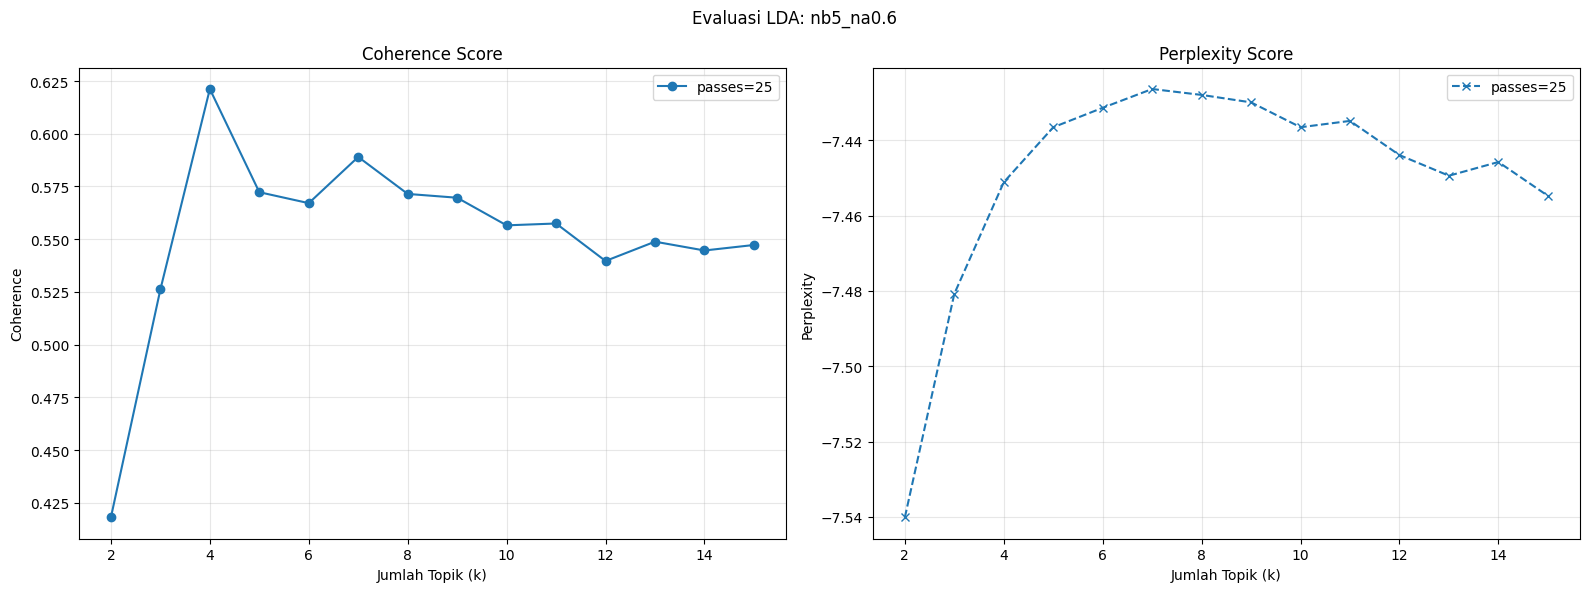

In [31]:
hasil_lemma = []

for label, data in gensim_skenario2.items():

    print(f"\n📊 Eksperimen: {label}")

    df_result = evaluate_lda_multi_passes(
        corpus=data['corpus'],
        dictionary=data['dict'],
        texts=df_lda['lemmatization'].tolist(),
        passes_list=passes_list
    )

    df_result["eksperimen"] = label
    df_result["no_below"] = data["no_below"]
    df_result["no_above"] = data["no_above"]

    hasil_lemma.append(df_result)

    plot_lda_results(df_result, label)

df_hasil_lemma = pd.concat(hasil_lemma).reset_index(drop=True)

In [32]:
df_hasil_lemma = pd.concat(hasil_lemma, ignore_index=True)

df_hasil_lemma["jumlah_vocab"] = df_hasil_lemma["eksperimen"].map(
    lambda x: len(gensim_skenario2[x]["dict"]))

print(f"Jumlah model terbaik (eksperimen x passes): {len(df_hasil_lemma)}")

display(
    df_hasil_lemma[
        [
            "eksperimen",
            "passes",
            "k",
            "coherence",
            "perplexity",
            "jumlah_vocab",
            "no_below",
            "no_above"
        ]
    ].sort_values(by="coherence", ascending=False).reset_index(drop=True))

df_hasil_lemma = pd.concat(hasil_lemma, ignore_index=True)

df_hasil_lemma["jumlah_vocab"] = df_hasil_lemma["eksperimen"].map(
    lambda x: len(gensim_skenario2[x]["dict"]))

Jumlah model terbaik (eksperimen x passes): 28


,eksperimen,passes,k,coherence,perplexity,jumlah_vocab,no_below,no_above
0,nb5_na0.6,25,4,0.621200,-7.451118,5383,5,0.60
1,nb5_na0.6,25,7,0.588988,-7.426359,5383,5,0.60
2,nb5_na0.6,25,5,0.572274,-7.436521,5383,5,0.60
3,nb5_na0.6,25,8,0.571451,-7.427929,5383,5,0.60
4,nb5_na0.6,25,9,0.569645,-7.429910,5383,5,0.60
5,nb5_na0.6,25,6,0.567073,-7.431346,5383,5,0.60
6,nb5_na0.6,25,11,0.557427,-7.434831,5383,5,0.60
7,nb5_na0.6,25,10,0.556552,-7.436511,5383,5,0.60
8,nb5_na0.6,25,13,0.548807,-7.449392,5383,5,0.60
9,nb5_na0.6,25,15,0.547237,-7.454728,5383,5,0.60


In [33]:
# df_hasil_lemma = hasil_lemma.loc[hasil_lemma.groupby(['eksperimen', 'passes'])['coherence'].idxmax()
# ].reset_index(drop=True)

# df_hasil_lemma = df_hasil_lemma.sort_values( # urutkan dari terbaik
#     by=["passes", "coherence"], ascending=False
# ).reset_index(drop=True)

# print(f"Jumlah model terbaik (eksperimen x passes): {len(df_hasil_lemma)}")
# display(df_hasil_lemma)

In [34]:
df_lemma_best = df_hasil_lemma.loc[
    df_hasil_lemma.groupby(['eksperimen', 'passes'])['coherence'].idxmax()
].reset_index(drop=True)

df_lemma_best = df_lemma_best.sort_values( # urutkan dari terbaik
    by=["passes", "coherence"], ascending=False
).reset_index(drop=True)

print(f"Jumlah model terbaik (eksperimen x passes): {len(df_lemma_best)}")
display(df_lemma_best)

Jumlah model terbaik (eksperimen x passes): 2


,k,passes,coherence,perplexity,model,eksperimen,no_below,no_above,jumlah_vocab
0,4,25,0.621200,-7.451118,"LdaModel<num_terms=5383, num_topics=4, decay=0...",nb5_na0.6,5,0.60,5383
1,11,25,0.439922,-7.923677,"LdaModel<num_terms=5003, num_topics=11, decay=...",nb5_na0.05,5,0.05,5003


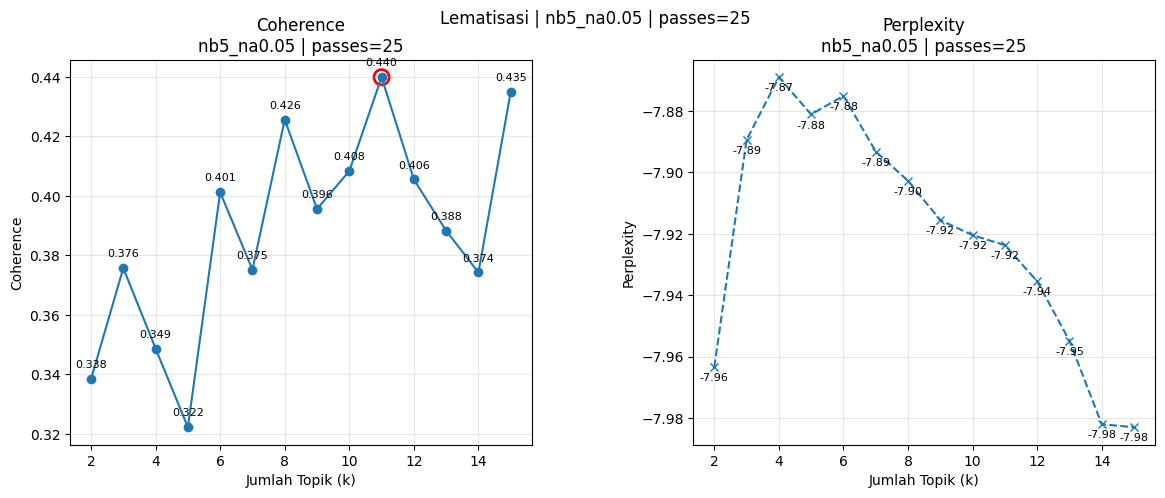

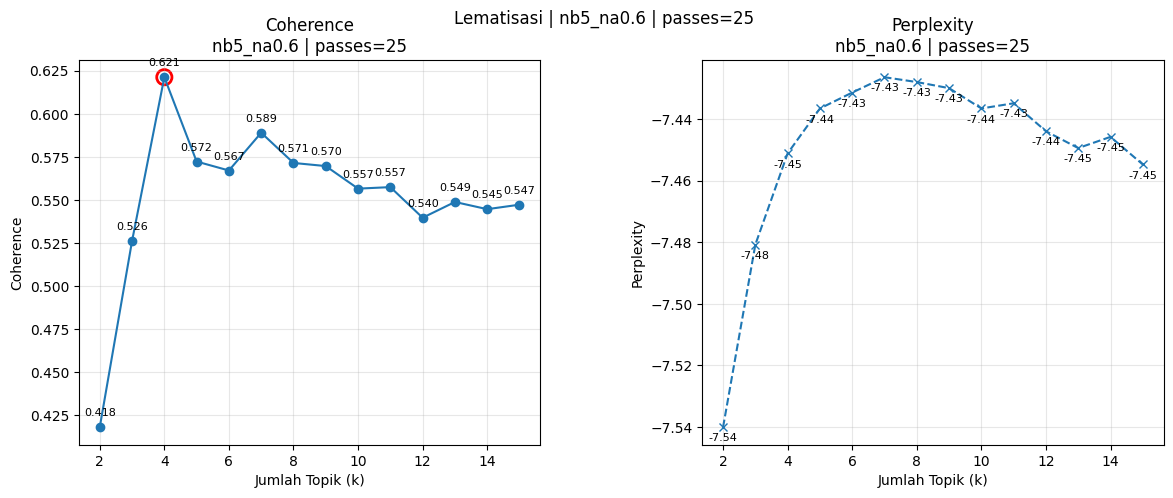

In [35]:
plot_best_lda(
    df_best=df_lemma_best,
    df_all=df_hasil_lemma,
    title_prefix="Lematisasi"
)

In [36]:
# save_lda_outputs(
#     df_best=df_lemma_best,
#     df_hasil=df_hasil_lemma,
#     gensim_dict=gensim_skenario2,
#     texts=df_lda['lemmatization'].tolist(),
#     df_source=df_lda,
#     text_col="lemmatization",
#     skenario_name="lemma"
# )

In [37]:
# os.makedirs("lda_results/lematisasi_topics", exist_ok=True)

for _, row in df_lemma_best.iterrows():

    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    print(f"\n{'='*60}")
    print(f"  {label} | k={k} | passes={passes}")
    print(f"{'='*60}")

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == label) &
        (df_hasil_lemma["k"] == k) &
        (df_hasil_lemma["passes"] == passes)
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]

    df_topic = extract_topic_info(lda_model, num_words=15)

    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_rows", None)
    print(df_topic[["Topik ID", "Kata Kunci Dominan", "Rumus Probabilitas"]].to_string(index=False))
    pd.reset_option("display.max_colwidth")
    pd.reset_option("display.max_rows")

    # output_path = (
    #     f"lda_results/lematisasi_topics/"
    #     f"{label}_k{k}_p{passes}_topics.csv"
    # )
    # df_topic.to_csv(output_path, index=False)
    # print(f"\n✔ saved: {output_path}")


  nb5_na0.6 | k=4 | passes=25
 Topik ID                                                                                                                                                       Kata Kunci Dominan                                                                                                                                                                                                                                                                                                            Rumus Probabilitas
        1                 Forecasting, Series, Model, Prediction, Term, Long_Short_Term_Memory, Accuracy, Neural, Long, Error, Short, Network, Feature, Transformer, Deep_Learning                 0.0205*"forecasting" + 0.0174*"series" + 0.0164*"model" + 0.0151*"prediction" + 0.0097*"term" + 0.0097*"long_short_term_memory" + 0.0090*"accuracy" + 0.0088*"neural" + 0.0077*"long" + 0.0069*"error" + 0.0064*"short" + 0.0053*"network" + 0.0053*"feature" + 0.0052*"transformer" 

In [42]:
# label topik lemma k=4

labels_lemma_nb5_na06_k4 = {
    1: "Forecasting Time Series",
    2: "Predictive Analytics",
    3: "Feature Selection ML",
    4: "Sentiment Media Sosial"
}


# label topik lemma k=11

labels_lemma_nb5_na005_k11 = {
    1: "IoT Smart Energy",
    2: "Spatial Spectral Image",
    3: "COVID News Education",
    4: "Cyber Attack Detection",
    5: "Fault Diagnosis System",
    6: "Urban Food Policy",
    7: "Medical Diagnosis Healthcare",
    8: "BERT Customer Sentiment",
    9: "Financial Stock Prediction",
    10: "Software Defect Detection",
    11: "Multimodal Analysis"
}


# fungsi tambah label topik

def add_labels(df_topic, label_dict):

    df = df_topic.copy()

    df.insert(
        1,
        "Label Topik",
        df["Topik ID"].map(label_dict)
    )

    return df


# simpan topic + label ke excel

os.makedirs("lda_results", exist_ok=True)

output_excel = "lda_results/lemma_topics_labeled.xlsx"


configs_lemma = [

    {
        "eksperimen": "lemma_nb5_na0.6",
        "k": 4,
        "passes": 25,
        "labels": labels_lemma_nb5_na06_k4,
        "sheet": "lemma_nb5_na0.6_k4"
    },

    {
        "eksperimen": "lemma_nb5_na0.05",
        "k": 11,
        "passes": 25,
        "labels": labels_lemma_nb5_na005_k11,
        "sheet": "lemma_nb5_na0.05_k11"
    }
]


with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    for cfg in configs_lemma:

        print(f"\n{'='*60}")
        print(f"{cfg['eksperimen']} | k={cfg['k']} | passes={cfg['passes']}")
        print(f"{'='*60}")

        model_row = df_hasil_lemma[
            (df_hasil_lemma["eksperimen"] == cfg["eksperimen"]) &
            (df_hasil_lemma["k"] == cfg["k"]) &
            (df_hasil_lemma["passes"] == cfg["passes"])
        ]

        if model_row.empty:
            print("Model tidak ditemukan")
            continue

        lda_model = model_row.iloc[0]["model"]

        df_topic = extract_topic_info(
            lda_model,
            num_words=15
        )

        df_labeled = add_labels(
            df_topic,
            cfg["labels"]
        )

        display(
            df_labeled[
                [
                    "Topik ID",
                    "Label Topik",
                    "Kata Kunci Dominan"
                ]
            ]
        )

        df_labeled.to_excel(
            writer,
            sheet_name=cfg["sheet"],
            index=False
        )

        ws = writer.sheets[cfg["sheet"]]

        for col in ws.columns:

            max_len = max(
                len(str(cell.value)) if cell.value else 0
                for cell in col
            )

            ws.column_dimensions[
                col[0].column_letter
            ].width = min(max_len + 4, 60)

        print(f"✔ sheet saved: {cfg['sheet']}")

print(f"\n✅ File Excel tersimpan di:\n{output_excel}")


lemma_nb5_na0.6 | k=4 | passes=25
Model tidak ditemukan

lemma_nb5_na0.05 | k=11 | passes=25
Model tidak ditemukan


IndexError: At least one sheet must be visible

In [ ]:
# gabungkan hasil topik lemma ke dataset

df_lemma = df_lda.copy()

os.makedirs("lda_dataset/lemma", exist_ok=True)

for cfg in configs_lemma:

    print(f"\nMemproses {cfg['eksperimen']}")

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == cfg["eksperimen"]) &
        (df_hasil_lemma["k"] == cfg["k"]) &
        (df_hasil_lemma["passes"] == cfg["passes"])
    ]

    if model_row.empty:
        print("Model tidak ditemukan")
        continue

    lda_model = model_row.iloc[0]["model"]

    corpus = gensim_skenario2[
        cfg["eksperimen"]
    ]["corpus"]

    k = cfg["k"]

    topic_vectors, dominant_topics = get_topic_distribution_full(
        lda_model,
        corpus,
        k
    )

    df_final = df_lemma.copy()

    df_final = df_final.rename(
        columns={
            "lemmatization": "lemma_text"
        }
    )

    df_final = df_final[
        [
            "Year",
            "clean_text",
            "lemma_text"
        ]
    ]

    for i in range(k):

        df_final[f"topic_{i+1}"] = topic_vectors[:, i]

    df_final["topik_dominan"] = [
        x[0] for x in dominant_topics
    ]

    df_final["probabilitas_topik"] = [
        x[1] for x in dominant_topics
    ]

    df_final["label_topik"] = df_final[
        "topik_dominan"
    ].map(cfg["labels"])

    output_path = (
        f"lda_dataset/lemma/"
        f"{cfg['eksperimen']}_k{cfg['k']}_p{cfg['passes']}.csv"
    )

    df_final.to_csv(
        output_path,
        index=False
    )

    print(f"✔ saved: {output_path}")

    display(df_final.head())

In [ ]:
!pip install pyLDAvis -q

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 57.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# folder output html
os.makedirs("lda_vis/nonlemma", exist_ok=True)
os.makedirs("lda_vis/lemma", exist_ok=True)

In [ ]:
# lematisasi
for _, row in df_lemma_best.iterrows():

    label = row["eksperimen"]
    k = int(row["k"])
    passes = int(row["passes"])

    model_row = df_hasil_lemma[
        (df_hasil_lemma["eksperimen"] == label) &
        (df_hasil_lemma["k"] == k) &
        (df_hasil_lemma["passes"] == passes)
    ]

    if model_row.empty:
        continue

    lda_model = model_row.iloc[0]["model"]

    corpus = gensim_skenario2[label]["corpus"]
    dictionary = gensim_skenario2[label]["dict"]

    vis = gensimvis.prepare(
        lda_model,
        corpus,
        dictionary,
        sort_topics=False
    )

    display(HTML(f"<h3>{label} | k={k} | passes={passes}</h3>"))
    display(pyLDAvis.display(vis))

# **04 Analisis Hasil & Perbandingan**

In [39]:
# rekapan 4 eksperimen terbaik
best_nonlemma_all = df_nonlemma_best.sort_values(by="coherence", ascending=False).reset_index(drop=True)
best_lemma_all = df_lemma_best.sort_values(by="coherence", ascending=False).reset_index(drop=True)
df_rekap_eksperimen = pd.concat([best_nonlemma_all, best_lemma_all]).reset_index(drop=True)

df_rekap_eksperimen["skenario"] = ["non_lematisasi"
    if "lemma" not in exp else "lematisasi" for exp in df_rekap_eksperimen["eksperimen"]]

df_rekap_eksperimen = df_rekap_eksperimen[
    ["skenario", "eksperimen", "passes", "k", "coherence", "perplexity"]]

df_rekap_eksperimen = df_rekap_eksperimen.sort_values(
    by="coherence", ascending=False).reset_index(drop=True)
display(df_rekap_eksperimen)

,skenario,eksperimen,passes,k,coherence,perplexity
0,non_lematisasi,nb5_na0.6,25,4,0.621200,-7.451118
1,non_lematisasi,nb5_na0.6,25,5,0.605171,-7.603399
2,non_lematisasi,nb5_na0.05,25,13,0.478314,-8.097389
3,non_lematisasi,nb5_na0.05,25,11,0.439922,-7.923677


## 4.1 Analisis Model Terbaik (Skenario Terpilih)

In [40]:
best_nonlemma_1 = df_nonlemma_best.sort_values("coherence", ascending=False).iloc[0]
best_lemma_1    = df_lemma_best.sort_values("coherence", ascending=False).iloc[0]

df_best_3 = pd.DataFrame([best_nonlemma_1, best_lemma_1]).reset_index(drop=True)

df_best_3 = df_best_3.sort_values(by="coherence", ascending=False).reset_index(drop=True)

df_best_3["skenario"] = ["lematisasi", "non_lematisasi",]

display(df_best_3[[
    "skenario","eksperimen","passes","k","coherence","perplexity"]])

,skenario,eksperimen,passes,k,coherence,perplexity
0,lematisasi,nb5_na0.6,25,4,0.621200,-7.451118
1,non_lematisasi,nb5_na0.6,25,5,0.605171,-7.603399


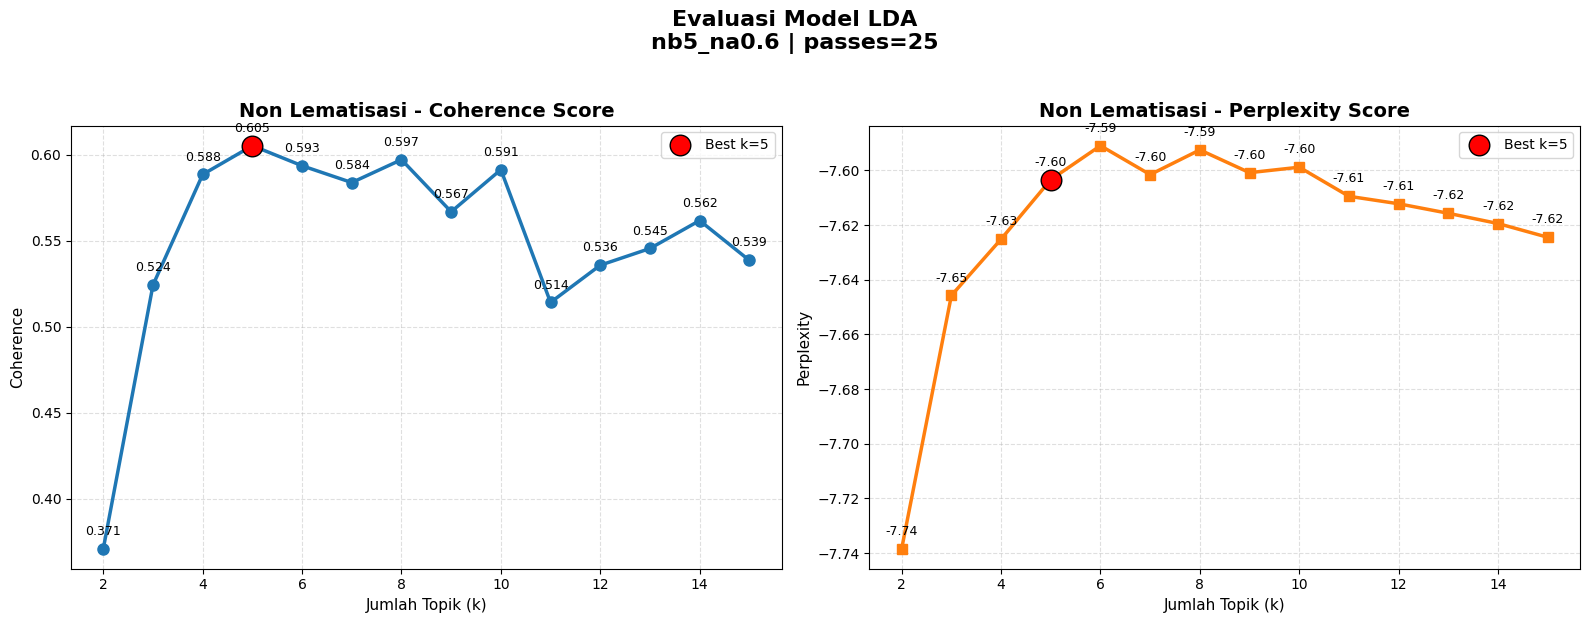

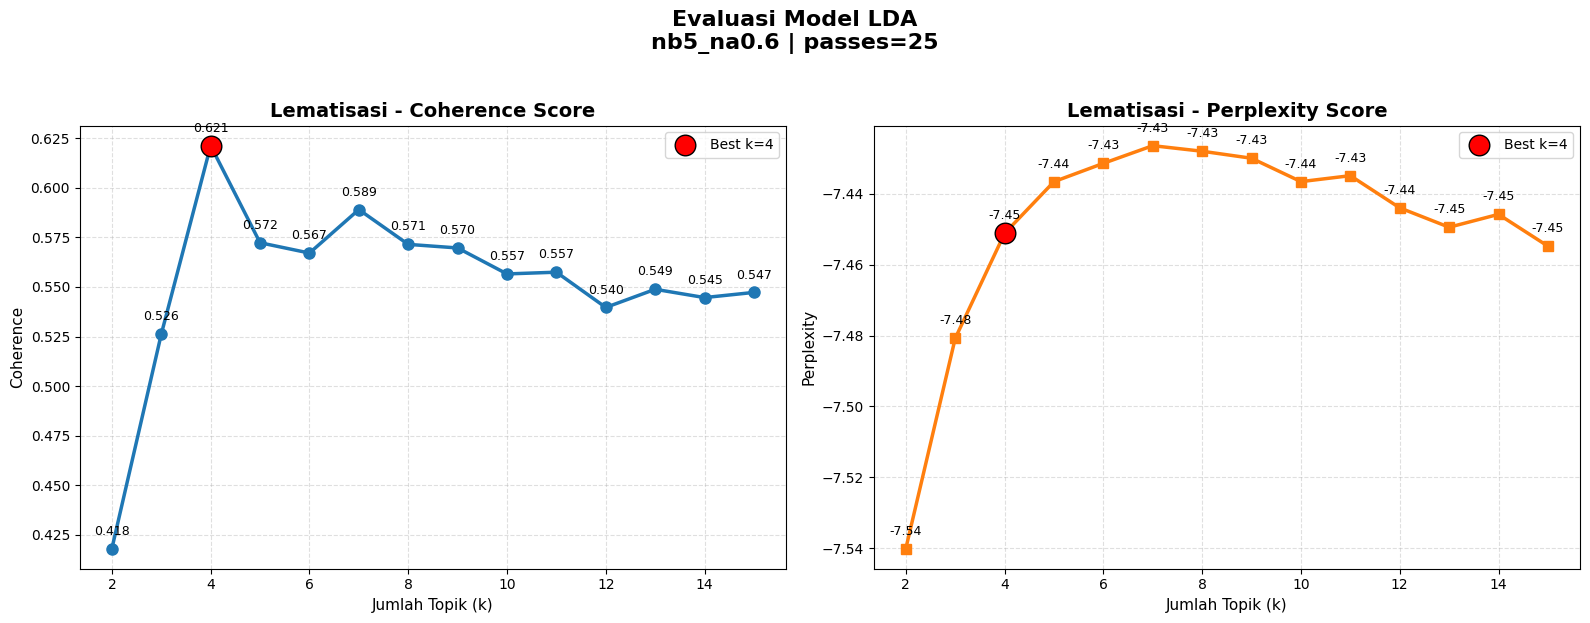

In [41]:
def plot_skenario_line(df_hasil, best_row, title):

    label = best_row["eksperimen"]
    passes = best_row["passes"]

    df_plot = df_hasil[
        (df_hasil["eksperimen"] == label) &
        (df_hasil["passes"] == passes)
    ].sort_values("k")

    best_k = best_row["k"]
    best_coh = best_row["coherence"]
    best_perp = best_row["perplexity"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # coherence
    axes[0].plot(
        df_plot["k"],
        df_plot["coherence"],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color='#1f77b4'
    )

    axes[0].scatter(
        best_k,
        best_coh,
        s=220,
        color='red',
        edgecolor='black',
        zorder=5,
        label=f'Best k={best_k}'
    )

    for _, row in df_plot.iterrows():

        axes[0].annotate(
            f"{row['coherence']:.3f}",
            (row["k"], row["coherence"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=9
        )

    axes[0].set_title(
        f"{title} - Coherence Score",
        fontsize=14,
        fontweight='bold'
    )

    axes[0].set_xlabel("Jumlah Topik (k)", fontsize=11)
    axes[0].set_ylabel("Coherence", fontsize=11)

    axes[0].grid(
        linestyle='--',
        alpha=0.4
    )

    axes[0].legend()

    # perplexity
    axes[1].plot(
        df_plot["k"],
        df_plot["perplexity"],
        marker='s',
        linewidth=2.5,
        markersize=7,
        color='#ff7f0e'
    )

    axes[1].scatter(
        best_k,
        best_perp,
        s=220,
        color='red',
        edgecolor='black',
        zorder=5,
        label=f'Best k={best_k}'
    )

    for _, row in df_plot.iterrows():

        axes[1].annotate(
            f"{row['perplexity']:.2f}",
            (row["k"], row["perplexity"]),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=9
        )

    axes[1].set_title(
        f"{title} - Perplexity Score",
        fontsize=14,
        fontweight='bold'
    )

    axes[1].set_xlabel("Jumlah Topik (k)", fontsize=11)
    axes[1].set_ylabel("Perplexity", fontsize=11)

    axes[1].grid(
        linestyle='--',
        alpha=0.4
    )

    axes[1].legend()

    plt.suptitle(
        f"Evaluasi Model LDA\n{label} | passes={passes}",
        fontsize=16,
        fontweight='bold',
        y=1.03
    )

    plt.tight_layout()
    plt.show()


plot_skenario_line(
    df_hasil_nonlemma,
    best_nonlemma_1,
    title="Non Lematisasi"
)

plot_skenario_line(
    df_hasil_lemma,
    best_lemma_1,
    title="Lematisasi"
)

## 4.2 Perbandingan Kata Kunci Antar Eksperimen

In [ ]:
# for _, row in df_best_3.iterrows():
#     label = row["eksperimen"]
#     model = row["model"]
#     skenario = row["skenario"]
#     k = row["k"]

#     print(f"\nSkenario : {skenario}")
#     print(f"Eksperimen : {label}")
#     print(f"Jumlah Topik : {k}")

#     df_topic = extract_topic_info(model, num_words=15)
#     display(df_topic)

In [ ]:
# os.makedirs("lda_dataset/final_3_models", exist_ok=True)

# for _, row in df_best_3.iterrows():
#     label = row["eksperimen"]
#     model = row["model"]
#     k = row["k"]
#     skenario = row["skenario"]

#     print(f"\nProcessing {label} ({skenario})")

#     # tentukan corpus sesuai skenario
#     if skenario == "non_lemma":
#         corpus = gensim_skenario1[label]["corpus"]
#         text_col = "stopword_removed"

#     elif skenario == "lemma":
#         corpus = gensim_skenario2[label]["corpus"]
#         text_col = "lemmatization"

#     else:
#         corpus = gensim_skenario3[label]["corpus"]
#         text_col = label.split("_nb")[0].replace("_no_filter","")

#     lda_vecs, dom_topics = get_topic_distribution_full(model, corpus, k)

#     df_out = pd.DataFrame({
#         "doc_id": df_lda.index,
#         "Year": df_lda["Year"],
#         "clean_text": df_lda["clean_text"],
#         "text": df_lda[text_col]
#     })

#     for i in range(k):
#         df_out[f"topic_{i+1}"] = lda_vecs[:, i]

#     df_out["topik_lda"] = [t[0] for t in dom_topics]
#     df_out["prob_topik"] = [t[1] for t in dom_topics]

#     output_path = f"lda_dataset/final_3_models/{skenario}_{label}_k{k}.csv"
#     df_out.to_csv(output_path, index=False)
#     print(output_path)

## 4.3 Penentuan Model Final

In [ ]:
final_model_row = df_best_3.sort_values(by="coherence", ascending=False).iloc[0]

print("MODEL FINAL TERPILIH:")
display(final_model_row[["skenario","eksperimen","passes","k","coherence","perplexity"]])

MODEL FINAL TERPILIH:


,0
skenario,lematisasi
eksperimen,unigram_lemma_nb5_na0.6
passes,25
k,4
coherence,0.6212
perplexity,-7.451118


## 4.4 Interpretasi dan Pelabelan Topik

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_final = pd.read_csv('/content/lematisasi_nb5_na0.6_k4_dataset.csv')
model_final

,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topik_dominan,probabilitas_topik,label_topik
0,2020,today digital world demands about automated se...,"['demand', 'automated', 'sentiment_analysis', ...",0.215532,0.002478,0.081011,0.700979,4,0.700979,Sentiment Media Sosial
1,2020,sentiment_analysis is focused on mining opinio...,"['sentiment_analysis', 'mining', 'opinion', 'c...",0.107206,0.001242,0.269512,0.622039,4,0.622039,Sentiment Media Sosial
2,2020,aspect_based_sentiment_analysis has recently a...,"['aspect_based_sentiment_analysis', 'attracted...",0.159668,0.001132,0.001398,0.837802,4,0.837802,Sentiment Media Sosial
3,2020,in the era of web online forums blogs and twit...,"['twitter', 'primary', 'source', 'view', 'opin...",0.001481,0.001859,0.520663,0.475996,3,0.520663,Feature Selection ML
4,2020,financial and economic news is continuously mo...,"['financial', 'economic', 'news', 'continuousl...",0.304786,0.088478,0.001459,0.605277,4,0.605277,Sentiment Media Sosial
...,...,...,...,...,...,...,...,...,...,...
3321,2026,this debate examines how climate change presen...,"['debate', 'examines', 'climate', 'present', '...",0.000614,0.926147,0.000949,0.072291,2,0.926147,Predictive Analytics
3322,2026,the current literature on electrical maintenan...,"['current', 'literature', 'electrical', 'maint...",0.000621,0.935992,0.000958,0.062429,2,0.935992,Predictive Analytics
3323,2026,this proposes a hybrid automated machine_learn...,"['hybrid', 'automated', 'machine_learning', 'a...",0.000712,0.450269,0.548307,0.000712,3,0.548307,Feature Selection ML
3324,2026,the rapid expansion of artificial intelligence...,"['rapid', 'expansion', 'artificial', 'intellig...",0.000644,0.669194,0.000994,0.329168,2,0.669194,Predictive Analytics


In [ ]:
topic_labels = {
    1: "Forecasting Model",
    2: "Predictive Analytics",
    3: "Machine Learning Classification",
    4: "Topic Sentimen Analisis"
}

df_interpretasi_topik = pd.DataFrame({"Topik ID": [1, 2, 3, 4],
    "Label Topik": [
        "Forecasting Model",
        "Predictive Analytics",
        "Machine Learning Classification",
        "NLP"],

    "Deskripsi": [
        "Topik membahas forecasting dan prediksi data menggunakan model deep learning seperti LSTM, neural network, dan transformer.",
        "Topik membahas predictive analytics untuk membantu proses pengambilan keputusan berbasis data menggunakan artificial intelligence dan machine learning.",
        "Topik membahas klasifikasi machine learning, feature selection, dimensionality reduction, dan optimasi model.",
        "Topik membahas natural language processing yang mencakup analisis sentimen, opini pengguna, dan pengolahan data teks."]})
display(df_interpretasi_topik)

,Topik ID,Label Topik,Deskripsi
0,1,Forecasting Model,Topik membahas forecasting dan prediksi data m...
1,2,Predictive Analytics,Topik membahas predictive analytics untuk memb...
2,3,Machine Learning Classification,"Topik membahas klasifikasi machine learning, f..."
3,4,NLP,Topik membahas natural language processing yan...


In [ ]:
# model_final = model_final.merge(df_interpretasi_topik,left_on="topik_dominan", right_on="Topik ID", how="left")
# model_final.head()

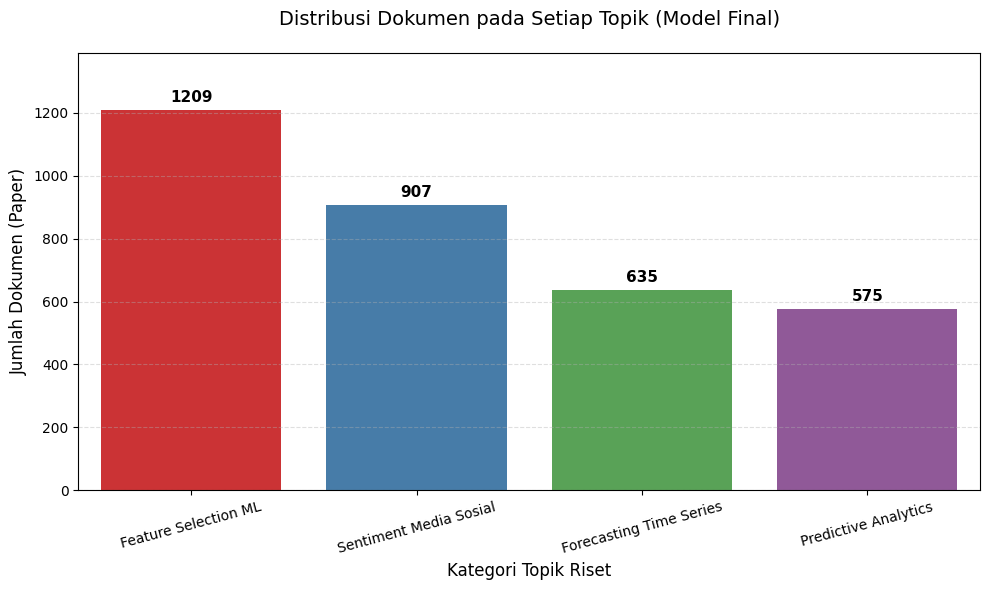

In [ ]:
plt.figure(figsize=(10, 6))

topic_order = model_final['label_topik'].value_counts().index

contrast_colors = [
    '#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
    '#ff7f00', '#ffff33', '#a65628', '#f781bf',
    '#1f78b4', '#33a02c', '#fb9a99', '#6a3d9a'
]

ax = sns.countplot(
    data=model_final,
    x='label_topik',
    order=topic_order,
    palette=contrast_colors[:len(topic_order)]
)

for p in ax.patches:

    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    "Distribusi Dokumen pada Setiap Topik (Model Final)",
    fontsize=14,
    pad=20
)

plt.xlabel("Kategori Topik Riset", fontsize=12)
plt.ylabel("Jumlah Dokumen (Paper)", fontsize=12)

plt.xticks(rotation=15)

plt.ylim(
    0,
    model_final['label_topik'].value_counts().max() * 1.15
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
df_distribusi_tahun = pd.crosstab(model_final["Year"], model_final["label_topik"], margins=True, margins_name="Total")
display(df_distribusi_tahun)

label_topik,Feature Selection ML,Forecasting Time Series,Predictive Analytics,Sentiment Media Sosial,Total
Year,,,,,
2020,186,58,29,110,383
2021,184,58,35,117,394
2022,189,78,42,138,447
2023,182,99,57,137,475
2024,169,122,125,157,573
2025,144,123,171,147,585
2026,155,97,116,101,469
Total,1209,635,575,907,3326


In [ ]:
model_final

,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topik_dominan,probabilitas_topik,label_topik
0,2020,today digital world demands about automated se...,"['demand', 'automated', 'sentiment_analysis', ...",0.215532,0.002478,0.081011,0.700979,4,0.700979,Sentiment Media Sosial
1,2020,sentiment_analysis is focused on mining opinio...,"['sentiment_analysis', 'mining', 'opinion', 'c...",0.107206,0.001242,0.269512,0.622039,4,0.622039,Sentiment Media Sosial
2,2020,aspect_based_sentiment_analysis has recently a...,"['aspect_based_sentiment_analysis', 'attracted...",0.159668,0.001132,0.001398,0.837802,4,0.837802,Sentiment Media Sosial
3,2020,in the era of web online forums blogs and twit...,"['twitter', 'primary', 'source', 'view', 'opin...",0.001481,0.001859,0.520663,0.475996,3,0.520663,Feature Selection ML
4,2020,financial and economic news is continuously mo...,"['financial', 'economic', 'news', 'continuousl...",0.304786,0.088478,0.001459,0.605277,4,0.605277,Sentiment Media Sosial
...,...,...,...,...,...,...,...,...,...,...
3321,2026,this debate examines how climate change presen...,"['debate', 'examines', 'climate', 'present', '...",0.000614,0.926147,0.000949,0.072291,2,0.926147,Predictive Analytics
3322,2026,the current literature on electrical maintenan...,"['current', 'literature', 'electrical', 'maint...",0.000621,0.935992,0.000958,0.062429,2,0.935992,Predictive Analytics
3323,2026,this proposes a hybrid automated machine_learn...,"['hybrid', 'automated', 'machine_learning', 'a...",0.000712,0.450269,0.548307,0.000712,3,0.548307,Feature Selection ML
3324,2026,the rapid expansion of artificial intelligence...,"['rapid', 'expansion', 'artificial', 'intellig...",0.000644,0.669194,0.000994,0.329168,2,0.669194,Predictive Analytics
